In [1]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))
sys.path.append(str(Path("../utils").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from data_loader import load_all_data, merge_commodities
from validation import validate_dataset

In [3]:
import data_loader

print(data_loader.__file__)

C:\Users\ujjwa\OneDrive\Documents\commodity-analytics\src\data_loader.py


In [4]:
import importlib
import data_loader

importlib.reload(data_loader)

<module 'data_loader' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\data_loader.py'>

In [5]:
import data_loader

print(dir(data_loader))

['PROJECT_ROOT', 'Path', 'RAW_DATA_PATH', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'load_all_data', 'load_data', 'merge_commodities', 'pd', 'reduce']


In [6]:
print(data_loader.PROJECT_ROOT)
print(data_loader.RAW_DATA_PATH)

C:\Users\ujjwa\OneDrive\Documents\commodity-analytics
C:\Users\ujjwa\OneDrive\Documents\commodity-analytics\data\raw


In [7]:
from data_loader import PROJECT_ROOT, RAW_DATA_PATH

print(PROJECT_ROOT)
print(RAW_DATA_PATH)
print(RAW_DATA_PATH.exists())
print(list(RAW_DATA_PATH.glob("*.csv")))

C:\Users\ujjwa\OneDrive\Documents\commodity-analytics
C:\Users\ujjwa\OneDrive\Documents\commodity-analytics\data\raw
True
[WindowsPath('C:/Users/ujjwa/OneDrive/Documents/commodity-analytics/data/raw/copper.csv'), WindowsPath('C:/Users/ujjwa/OneDrive/Documents/commodity-analytics/data/raw/crude_oil.csv'), WindowsPath('C:/Users/ujjwa/OneDrive/Documents/commodity-analytics/data/raw/gold.csv'), WindowsPath('C:/Users/ujjwa/OneDrive/Documents/commodity-analytics/data/raw/natural_gas.csv'), WindowsPath('C:/Users/ujjwa/OneDrive/Documents/commodity-analytics/data/raw/silver.csv')]


In [8]:
commodities = load_all_data()

gold = commodities["gold"]
silver = commodities["silver"]
oil = commodities["crude_oil"]
gas = commodities["natural_gas"]
copper = commodities["copper"]

merged = merge_commodities(commodities)

In [9]:
merged.head()

,Date,gold,silver,crude_oil,natural_gas,copper
0,2015-01-02,1186.000000,15.734000,52.689999,3.003,2.8385
1,2015-01-05,1203.900024,16.179001,50.040001,2.882,2.7930
2,2015-01-06,1219.300049,16.603001,47.930000,2.938,2.8040
3,2015-01-07,1210.599976,16.510000,48.650002,2.871,2.7960
4,2015-01-08,1208.400024,16.351000,48.790001,2.927,2.8070


In [10]:
from analytics import commodity_profile

profile = commodity_profile(merged)

profile

,Commodity,Start Price,Latest Price,Minimum,Maximum,Mean,Median,Std Dev,Total Return (%),Annualized Volatility (%)
0,Gold,1186.00,4104.10,1050.80,5318.40,1901.03,1732.00,886.24,246.05,16.53
1,Silver,15.73,59.81,11.73,115.08,24.40,20.00,14.03,280.13,33.42
2,Crude Oil,52.69,71.41,-37.63,123.70,63.14,61.97,17.80,35.53,108.28
3,Natural Gas,3.00,2.94,1.48,9.68,3.17,2.84,1.33,-2.10,66.50
4,Copper,2.84,6.23,1.94,6.65,3.49,3.20,1.02,119.61,24.27


## Commodity Profile Analysis

The table above provides a high-level summary of the historical performance and risk characteristics of the five commodities included in this analysis. Before performing any detailed exploratory analysis, it is useful to understand how each commodity has behaved over the observed period (2015–2026).

### Key Observations

#### 🥇 Gold
- Delivered a **246.05% total return**, making it one of the strongest long-term performers.
- Exhibited the **lowest annualized volatility (16.53%)**, indicating relatively stable price movements.
- This supports gold's traditional role as a **safe-haven asset** during periods of economic uncertainty.
- The recorded maximum price (~5318) appears unusually high and will be investigated later during outlier analysis.

---

#### 🥈 Silver
- Generated the **highest total return (280.13%)** among all commodities.
- However, its **annualized volatility (33.42%)** is approximately twice that of gold.
- Silver appears to offer higher growth potential at the cost of increased risk.

---

#### 🛢️ Crude Oil
- Produced only **35.53% total return** over the study period.
- Recorded the **highest annualized volatility (108.28%)**, making it the riskiest commodity in the dataset.
- The minimum closing price of **-37.63 USD** corresponds to the historic negative WTI crude oil prices observed during April 2020, confirming that the dataset captures real-world market events.

---

#### 🔥 Natural Gas
- Returned **-2.10%** over the entire period.
- Despite the negative long-term return, it exhibited **high volatility (66.50%)**.
- This indicates that natural gas experienced significant price fluctuations without generating sustained long-term appreciation.

---

#### 🏭 Copper
- Achieved a **119.61% total return**.
- Maintained a relatively moderate **annualized volatility (24.27%)**.
- Copper demonstrates a balanced combination of growth and risk, reflecting its importance as a widely used industrial commodity.

---

## Comparative Analysis

### Total Return Ranking

| Rank | Commodity | Total Return |
|------|-----------|-------------:|
| 1 | Silver | 280.13% |
| 2 | Gold | 246.05% |
| 3 | Copper | 119.61% |
| 4 | Crude Oil | 35.53% |
| 5 | Natural Gas | -2.10% |

---

### Annualized Volatility Ranking

| Rank | Commodity | Annualized Volatility |
|------|-----------|----------------------:|
| 1 | Crude Oil | 108.28% |
| 2 | Natural Gas | 66.50% |
| 3 | Silver | 33.42% |
| 4 | Copper | 24.27% |
| 5 | Gold | 16.53% |

---

## Overall Insights

The commodity profile highlights the trade-off between **risk and return** across different asset classes.

- **Gold** delivered strong long-term appreciation while maintaining the lowest volatility, reinforcing its reputation as a defensive investment.
- **Silver** produced the highest returns but required investors to tolerate substantially higher price fluctuations.
- **Copper** offered a balanced profile with healthy returns and moderate risk, making it one of the more stable industrial commodities.
- **Crude Oil** was the most volatile commodity, reflecting its sensitivity to geopolitical events, global demand, and supply disruptions.
- **Natural Gas** exhibited high volatility but generated almost no long-term capital appreciation, making it the weakest performer from a buy-and-hold perspective.

These observations establish a baseline understanding of each commodity before conducting deeper exploratory analyses, including trend analysis, return distributions, volatility dynamics, correlation analysis, and forecasting.

In [11]:
from visualisation import plot_price_history

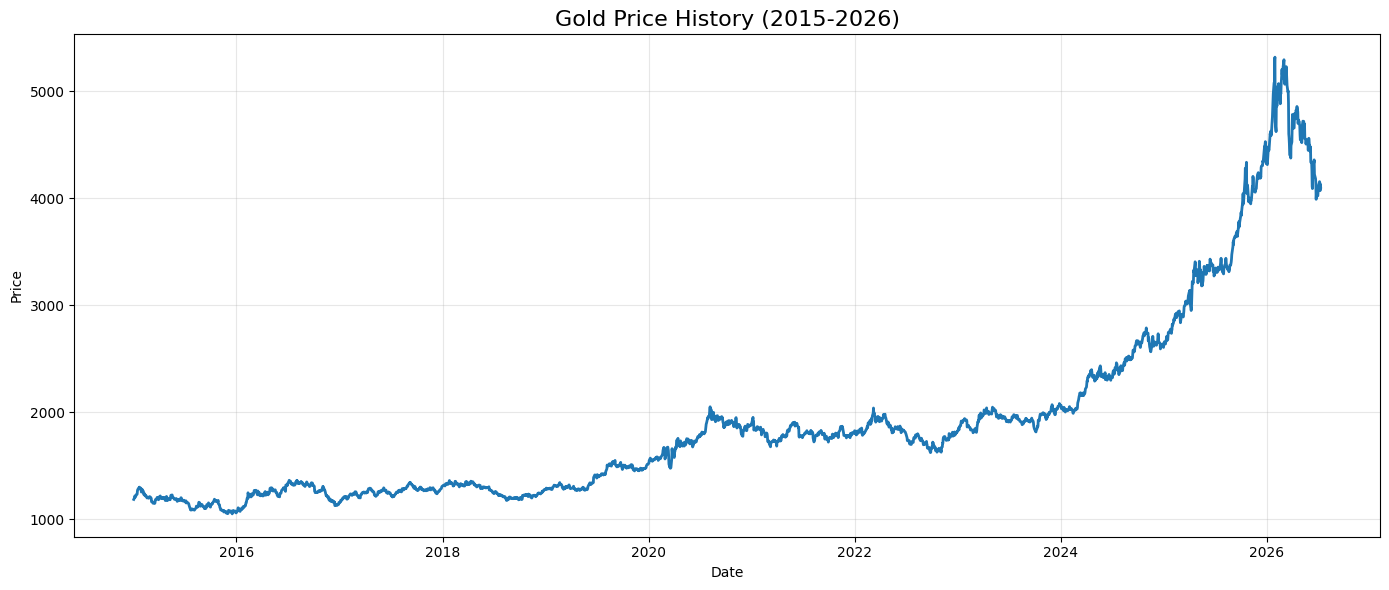

In [12]:
plot_price_history(gold,"Gold")

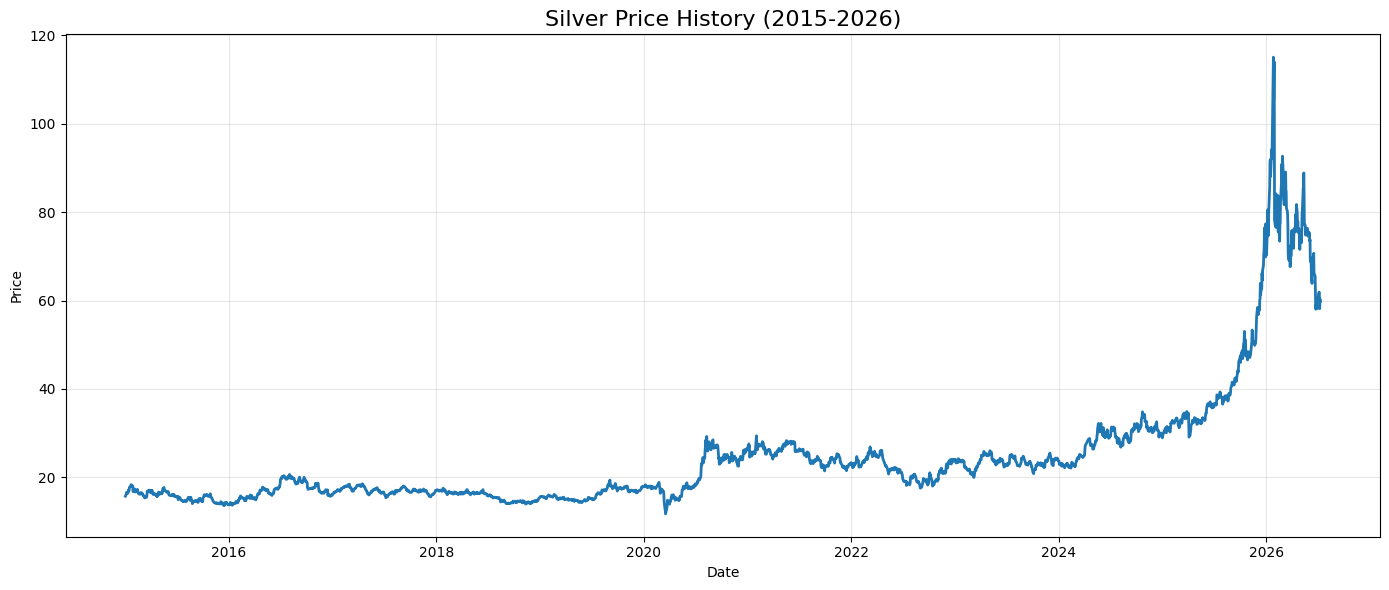

In [13]:
plot_price_history(silver, "Silver")

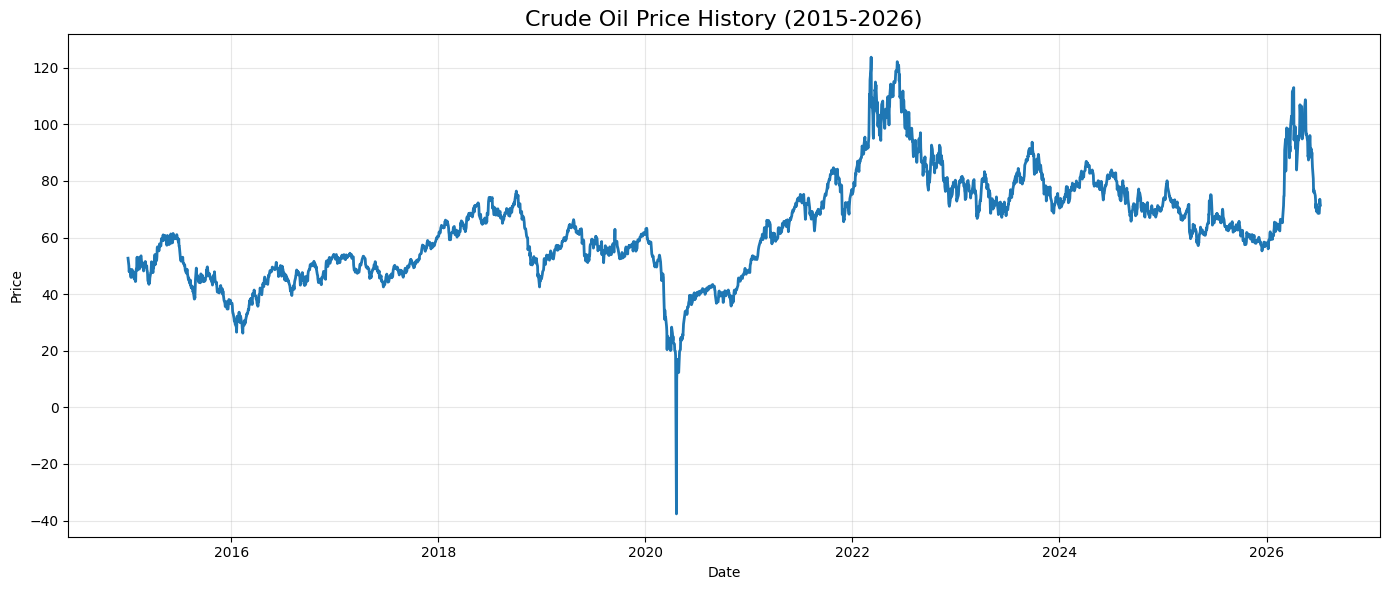

In [14]:
plot_price_history(oil, "Crude Oil")

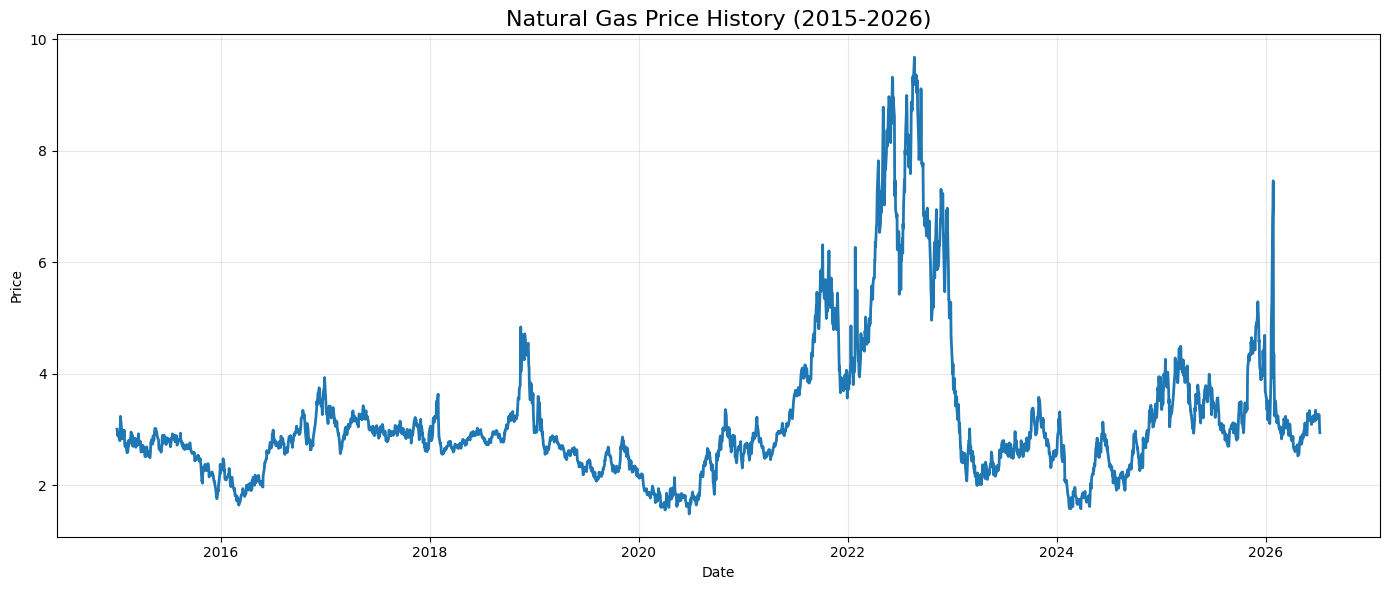

In [15]:
plot_price_history(gas, "Natural Gas")

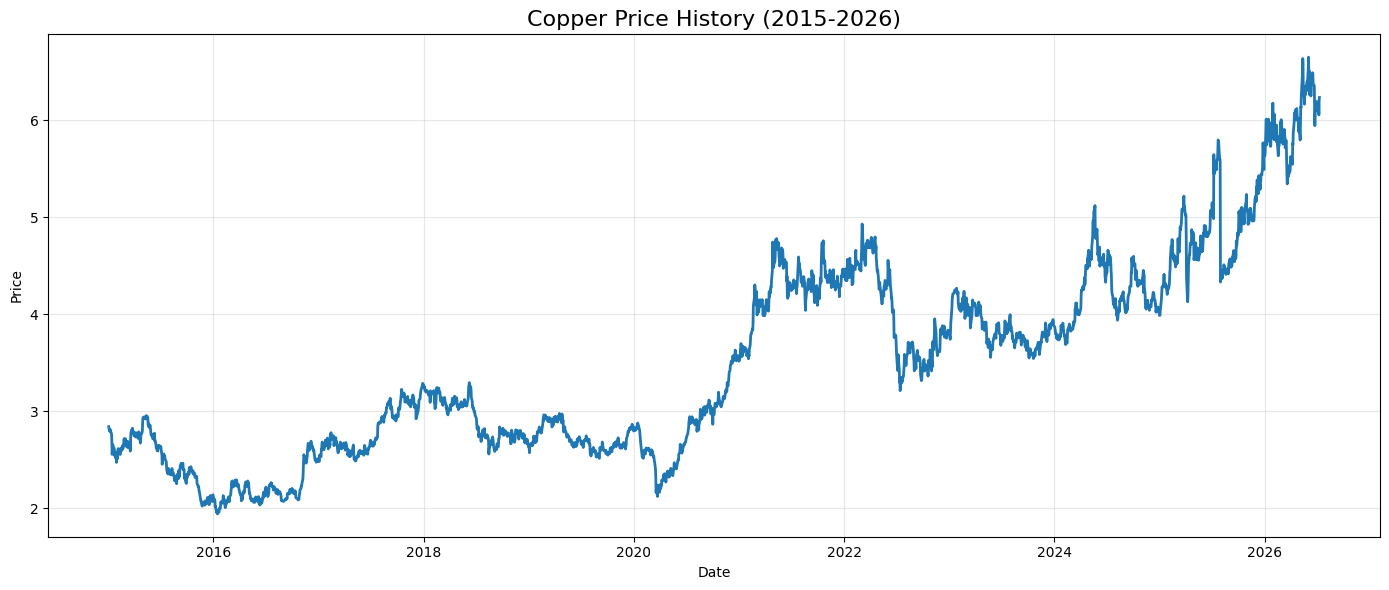

In [16]:
plot_price_history(copper, "Copper")

# Historical Price Trend Analysis

## Objective

The purpose of this analysis is to understand the long-term price behavior of major commodities from 2015 to 2026. By examining historical trends, we identify periods of growth, volatility, market shocks, and structural changes that may influence future forecasting and risk assessment.

---

# Gold Price History

### Observations

**2015–2019: Stable Trading Period**

Gold remained relatively range-bound, fluctuating between approximately **$1,000 and $1,400**. During this period, price movements were comparatively stable with limited directional momentum.

**2020–2023: Gradual Uptrend**

Gold entered a higher price regime, trading mostly between **$1,600 and $2,000**. The upward movement coincided with increased market uncertainty, inflation concerns, and changes in global monetary conditions.

**2024–2026: Strong Bull Market**

Gold experienced an exceptional rally, increasing from around **$2,000 to above $5,000** before undergoing a correction toward the **$4,000 range**.

### Analyst Interpretation

Gold demonstrated strong long-term appreciation while maintaining relatively lower volatility compared with other commodities. The sharp acceleration after 2024 represents a structural shift that requires further investigation through volatility analysis and anomaly detection.

---

# Silver Price History

### Observations

**2015–2019: Low Volatility Consolidation**

Silver traded within a narrow range between approximately **$14 and $20**, showing limited momentum.

**2020: Market Shock and Recovery**

During the initial COVID-19 market disruption, silver experienced a sharp decline followed by a rapid recovery toward the **$25–$30 range**.

**2021–2024: Consolidation Phase**

Silver moved within a broader range of approximately **$18–$30**, displaying moderate cyclical behavior.

**2025–2026: Extreme Bull Run**

Silver followed gold's upward movement, experiencing a rapid increase toward **$115** before correcting back toward the **$60 range**.

### Analyst Interpretation

Silver generated higher returns than gold but displayed significantly greater volatility. Its industrial demand component combined with precious-metal characteristics makes it more sensitive to both economic growth and investor sentiment.

---

# Crude Oil Price History

### Observations

**2015–2019: Cyclical Price Movement**

Crude oil fluctuated mainly between **$30 and $80**, reflecting typical supply-demand cycles.

**2020: Historic Market Shock**

Oil experienced an unprecedented collapse, reaching approximately **-$40** due to a combination of demand destruction, storage limitations, and market imbalance during the COVID-19 pandemic.

**2021–2022: Strong Recovery**

Prices recovered sharply, exceeding **$120** as global demand recovered and geopolitical tensions affected supply.

**2023–2025: Stabilization Period**

Oil prices gradually declined and stabilized within the **$60–$80 range**.

**2026: Temporary Spike**

A short-term rally pushed prices above **$100**, followed by a correction.

### Analyst Interpretation

Crude oil is the most volatile commodity in the dataset. Its price behavior is strongly influenced by geopolitical events, production decisions, and global economic conditions, making it a high-risk asset.

---

# Natural Gas Price History

### Observations

**2015–2020: Low Price Environment**

Natural gas remained mostly between **$2 and $4**, with relatively limited movement.

**2021–2022: Energy Crisis Spike**

Prices increased sharply, reaching nearly **$10**, driven by supply constraints and global energy market disruptions.

**2023–2024: Rapid Correction**

Prices declined significantly as supply conditions improved.

**2025–2026: Renewed Volatility**

Natural gas experienced another temporary spike before returning closer to historical levels.

### Analyst Interpretation

Natural gas displayed high volatility without strong long-term price appreciation. This indicates significant short-term risk exposure and sensitivity to supply-side disruptions.

---

# Copper Price History

### Observations

**2015–2020: Stable Trading Range**

Copper traded between approximately **$2 and $3.50**, showing limited long-term movement.

**2021–2022: Industrial Demand Rally**

Prices increased toward **$5**, supported by economic recovery, infrastructure demand, and electrification trends.

**2022–2024: Correction and Consolidation**

Copper entered a stabilization phase, trading between approximately **$3.20 and $4.50**.

**2024–2026: Structural Growth Trend**

Copper moved into a strong upward trend, reaching record levels above **$6.50**.

### Analyst Interpretation

Copper shows characteristics of a growth-sensitive industrial commodity. Its long-term appreciation reflects increasing demand from sectors such as renewable energy, electric vehicles, and infrastructure development.

---

# Overall Historical Trend Insights

The historical analysis reveals significant differences in commodity behavior:

| Commodity | Main Characteristics |
|---|---|
| Gold | Defensive asset with strong appreciation and relatively low volatility |
| Silver | High-return precious metal with increased risk |
| Crude Oil | Highly volatile commodity affected by global shocks |
| Natural Gas | Extreme volatility with weak long-term returns |
| Copper | Growth-oriented industrial commodity with structural demand |

These observations provide the foundation for the next stages of analysis, including moving average trends, return distributions, volatility modeling, correlation analysis, and forecasting.

MOVING AVERAGE TREND ANALYSIS
Business Question

Is a commodity currently trending upward, downward, or moving sideways?

Moving averages help answer:

Is the current price above or below its historical trend?
Has momentum changed recently?
Are there possible trend reversals?

Moving Average (MA)

A moving average calculates the average price over a rolling window.

Example:

30-Day Moving Average

For day 30:

MA
30
	​

=
30
P
1
	​

+P
2
	​

+...+P
30
	​

	​


For day 31:

MA
30
	​

=
30
P
2
	​

+P
3
	​

+...+P
31
	​

	​


The window continuously moves forward.

Why use 30 and 90 days?
30-Day MA

Represents:

Short-term trend
Recent market momentum
Approximately 1.5 trading months
90-Day MA

Represents:

Medium-term trend
Quarterly market direction

Interpretation Rules
Bullish Trend

When:

Price > MA30 > MA90

Meaning:

Current price is above recent average
Recent momentum is stronger than long-term trend

Bearish Trend

When:

Price < MA30 < MA90

Meaning:

Weak short-term momentum
Downward pressure


Trend Transition

When:

MA30 crosses MA90

This is called:

Moving Average Crossover




In [17]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [18]:
from analytics import add_moving_averages

In [19]:
gold_ma = add_moving_averages(gold)

gold_ma.head(35)

,Adj Close,Close,High,Low,Open,Volume,MA_30,MA_90
Date,,,,,,,,
2015-01-02,1186.000000,1186.000000,1194.500000,1169.500000,1184.000000,138,NaN,NaN
2015-01-05,1203.900024,1203.900024,1206.900024,1180.099976,1180.300049,470,NaN,NaN
2015-01-06,1219.300049,1219.300049,1220.000000,1203.500000,1203.500000,97,NaN,NaN
2015-01-07,1210.599976,1210.599976,1219.199951,1210.599976,1219.199951,29,NaN,NaN
2015-01-08,1208.400024,1208.400024,1215.699951,1206.300049,1207.000000,92,NaN,NaN
2015-01-09,1216.000000,1216.000000,1220.199951,1210.300049,1211.099976,43,NaN,NaN
2015-01-12,1232.699951,1232.699951,1234.400024,1219.099976,1224.199951,100,NaN,NaN
2015-01-13,1234.300049,1234.300049,1239.300049,1230.300049,1239.199951,20,NaN,NaN
2015-01-14,1234.400024,1234.400024,1243.800049,1225.599976,1229.599976,21,NaN,NaN


In [20]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

In [21]:
from visualisation import plot_moving_average

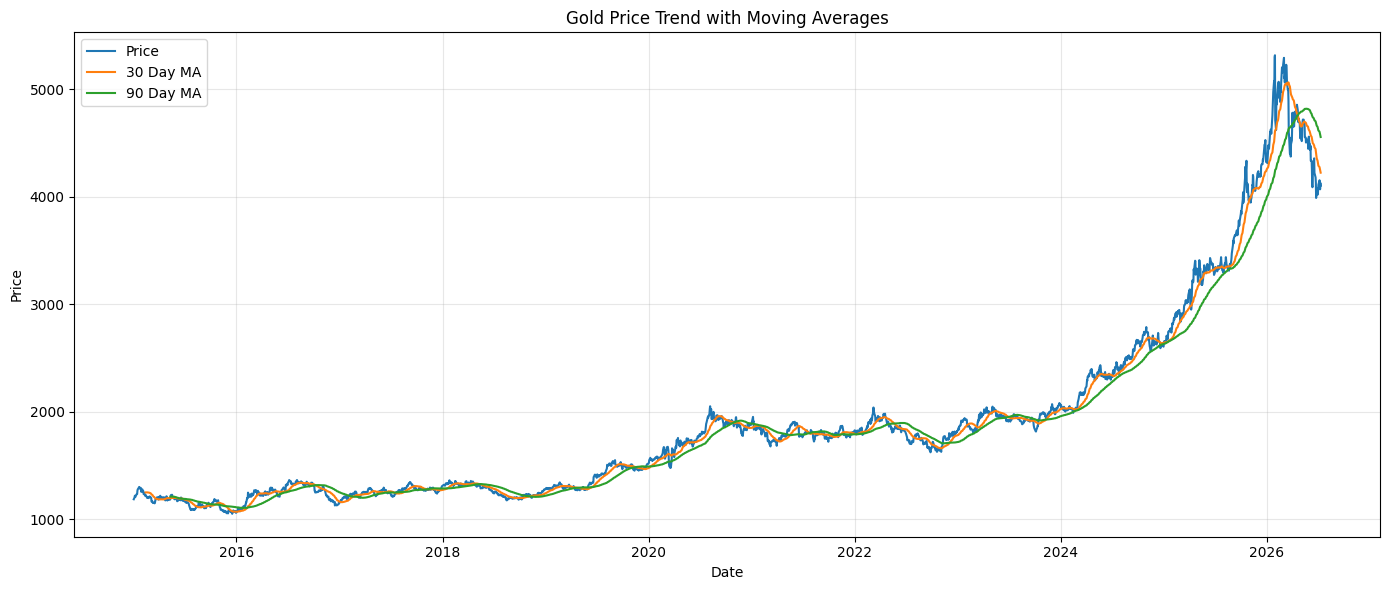

In [22]:
plot_moving_average(
    gold_ma,
    "Gold"
)

In [23]:
silver_ma = add_moving_averages(silver)

silver_ma.head(35)

,Adj Close,Close,High,Low,Open,Volume,MA_30,MA_90
Date,,,,,,,,
2015-01-02,15.734000,15.734000,15.815000,15.535000,15.790000,13,NaN,NaN
2015-01-05,16.179001,16.179001,16.179001,16.179001,16.179001,0,NaN,NaN
2015-01-06,16.603001,16.603001,16.603001,16.603001,16.603001,2,NaN,NaN
2015-01-07,16.510000,16.510000,16.549999,16.480000,16.480000,9,NaN,NaN
2015-01-08,16.351000,16.351000,16.351000,16.351000,16.351000,0,NaN,NaN
2015-01-09,16.386000,16.386000,16.386000,16.386000,16.386000,0,NaN,NaN
2015-01-12,16.535000,16.535000,16.535000,16.535000,16.535000,0,NaN,NaN
2015-01-13,17.125000,17.125000,17.125000,17.000000,17.000000,484,NaN,NaN
2015-01-14,16.955999,16.955999,16.955999,16.900000,16.900000,13,NaN,NaN


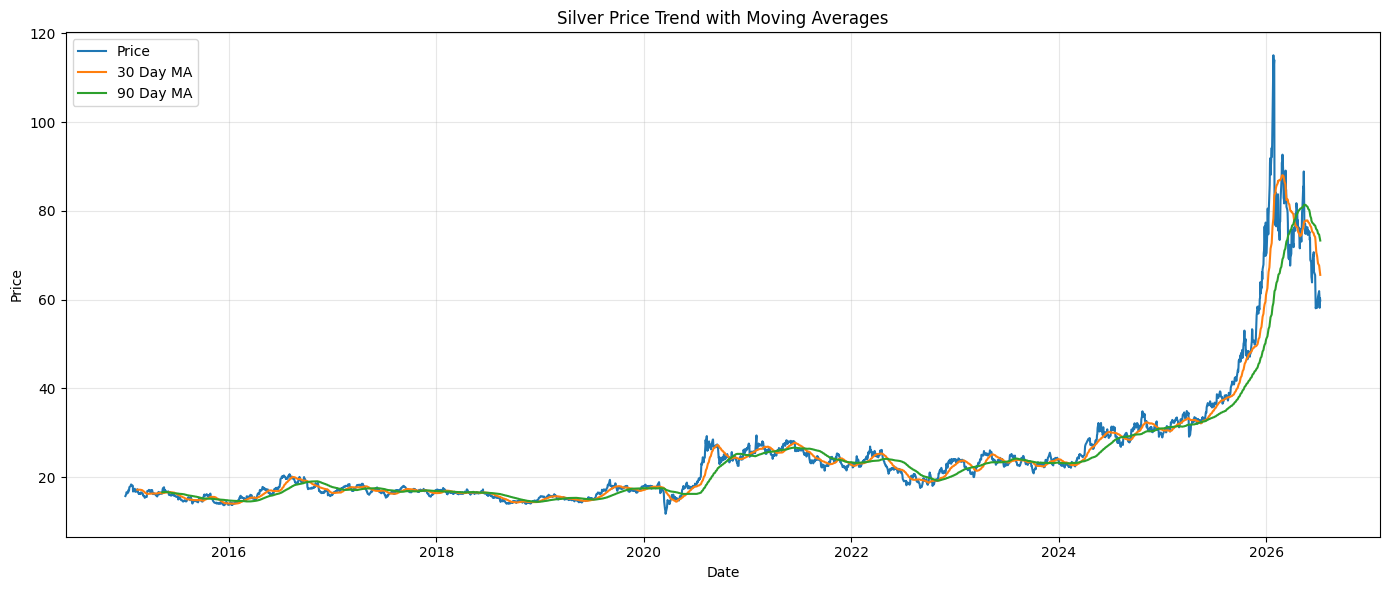

In [24]:
plot_moving_average(
    silver_ma,
    "Silver"
)

In [25]:
oil_ma = add_moving_averages(oil)

oil_ma.head(35)

,Adj Close,Close,High,Low,Open,Volume,MA_30,MA_90
Date,,,,,,,,
2015-01-02,52.689999,52.689999,55.110001,52.029999,53.759998,268708,NaN,NaN
2015-01-05,50.040001,50.040001,52.730000,49.680000,52.610001,375782,NaN,NaN
2015-01-06,47.930000,47.930000,50.369999,47.549999,50.000000,451642,NaN,NaN
2015-01-07,48.650002,48.650002,49.310001,46.830002,48.000000,460083,NaN,NaN
2015-01-08,48.790001,48.790001,49.650002,47.730000,48.779999,362081,NaN,NaN
2015-01-09,48.360001,48.360001,49.610001,47.160000,48.919998,421007,NaN,NaN
2015-01-12,46.070000,46.070000,48.189999,45.619999,48.189999,394946,NaN,NaN
2015-01-13,45.889999,45.889999,46.790001,44.200001,45.689999,476541,NaN,NaN
2015-01-14,48.480000,48.480000,48.910000,45.009998,46.160000,510252,NaN,NaN


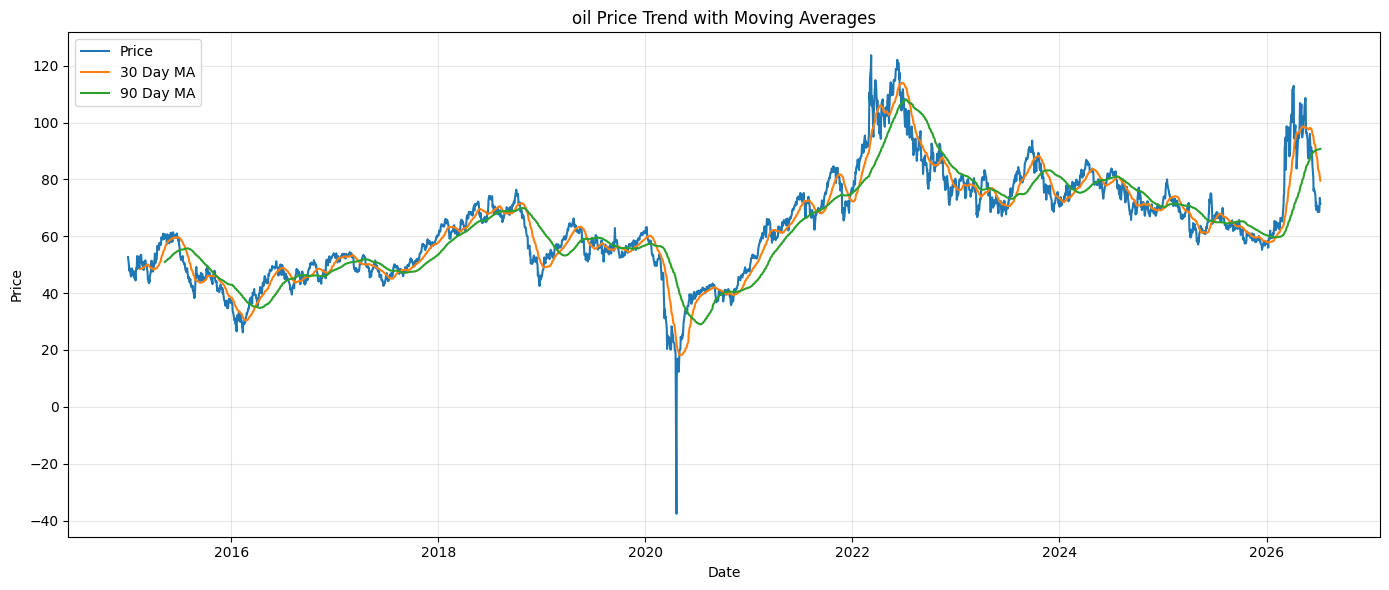

In [26]:
plot_moving_average(
    oil_ma,
    "oil"
)

In [27]:
gas_ma = add_moving_averages(gas)

gas_ma.head(35)

,Adj Close,Close,High,Low,Open,Volume,MA_30,MA_90
Date,,,,,,,,
2015-01-02,3.003,3.003,3.096,2.805,2.845,109122,NaN,NaN
2015-01-05,2.882,2.882,3.176,2.875,3.076,141783,NaN,NaN
2015-01-06,2.938,2.938,2.955,2.811,2.921,111338,NaN,NaN
2015-01-07,2.871,2.871,3.012,2.825,2.949,134826,NaN,NaN
2015-01-08,2.927,2.927,2.968,2.816,2.877,147797,NaN,NaN
2015-01-09,2.946,2.946,2.990,2.888,2.959,107333,NaN,NaN
2015-01-12,2.795,2.795,2.934,2.783,2.917,130404,NaN,NaN
2015-01-13,2.943,2.943,2.971,2.795,2.815,137906,NaN,NaN
2015-01-14,3.233,3.233,3.337,2.932,2.954,233230,NaN,NaN


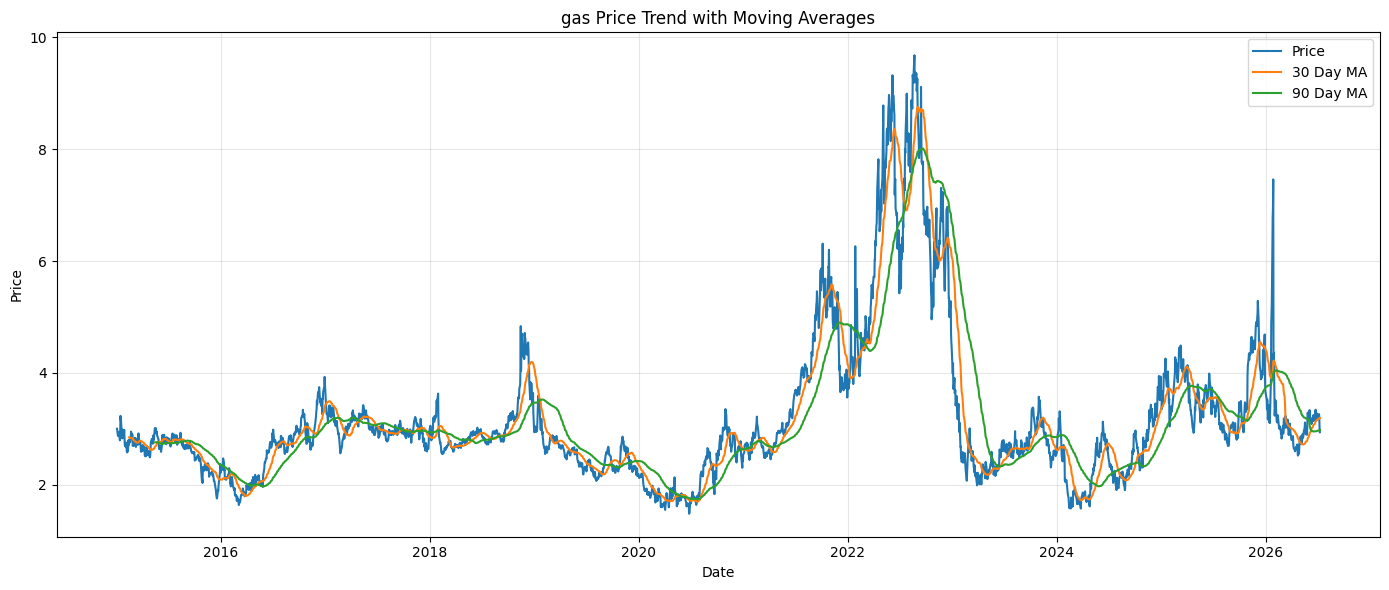

In [28]:
plot_moving_average(
   gas_ma,
   "gas"
)

In [29]:
copper_ma = add_moving_averages(copper)

copper_ma.head(35)

,Adj Close,Close,High,Low,Open,Volume,MA_30,MA_90
Date,,,,,,,,
2015-01-02,2.8385,2.8385,2.8420,2.8365,2.8420,220,NaN,NaN
2015-01-05,2.7930,2.7930,2.8295,2.7880,2.8295,326,NaN,NaN
2015-01-06,2.8040,2.8040,2.8060,2.7915,2.7950,312,NaN,NaN
2015-01-07,2.7960,2.7960,2.8090,2.7910,2.7920,463,NaN,NaN
2015-01-08,2.8070,2.8070,2.8175,2.7865,2.7960,242,NaN,NaN
2015-01-09,2.7905,2.7905,2.8080,2.7880,2.8040,303,NaN,NaN
2015-01-12,2.7630,2.7630,2.7935,2.7455,2.7935,311,NaN,NaN
2015-01-13,2.6790,2.6790,2.7595,2.6350,2.7595,599,NaN,NaN
2015-01-14,2.5530,2.5530,2.6480,2.4995,2.6480,328,NaN,NaN


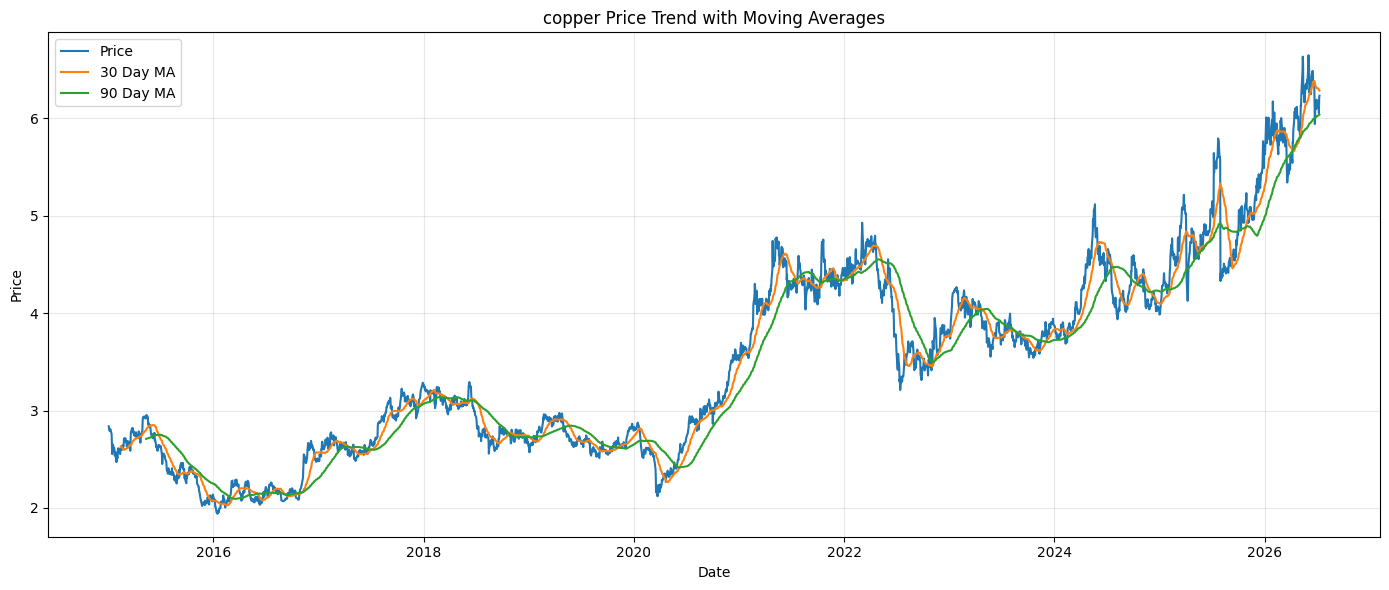

In [30]:
plot_moving_average(
    copper_ma,
    "copper"
)

Commodity Market Insights
Gold: A stable, long-term secular uptrend. Corrections consistently form higher lows, and the post-2024 breakout maintains a strong bullish structure where the MA30 stays above the MA90.

Silver: A higher-beta version of Gold. It offers explosive upside but suffers from high volatility and sideways consolidation, leading to more frequent moving average crossovers and false signals.

Oil: Deeply cyclical and driven by supply shocks. Extreme events (like the 2020 crash) create huge price-to-MA divergence because the moving averages lag significantly behind rapid price collapses.

Natural Gas: Exceptionally volatile and mean-reverting. Driven by weather and seasonality, its price spikes are sharp but short-lived, making it poorly suited for long-term trend following.

Copper: A proxy for global industrial growth (EVs, green energy). It exhibits a smooth, structural long-term expansion and respects moving averages well, with the MA90 frequently acting as support.


Commodity,Long-Term Trend,Volatility,Moving Average Behavior
Gold,Strong Bullish,Medium,Clean structure; clear support
Silver,Bullish / Explosive,High,Frequent crossovers; noisy
Oil,Cyclical,Very High,Significant lag during shocks
Natural Gas,Mean-Reverting,Extremely High,Frequent reversals; short trends
Copper,Structural Growth,Moderate,Smooth trends; respects MA90

return analytics:
A return measures the percentage change in price over a period.

Formula:

Return=

(Current Price−Previous Price)/previous price
	​


Log Return

Formula:

log(Pt/pt-1)
Because:

Returns become additive
Better for statistical models
Used commonly in quantitative finance


CAGR (Compound Annual Growth Rate)

Very important finance metric.

CAGR=((Beginning Value/Ending Value​)^1/n)−1

In [39]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [32]:
from analytics import add_returns

In [33]:
gold_returns = add_returns(gold)

silver_returns = add_returns(silver)

oil_returns = add_returns(oil)

gas_returns = add_returns(gas)

copper_returns = add_returns(copper)

In [34]:
gold_returns.head()

,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,,
2015-01-02,1186.000000,1186.000000,1194.500000,1169.500000,1184.000000,138,NaN
2015-01-05,1203.900024,1203.900024,1206.900024,1180.099976,1180.300049,470,0.015093
2015-01-06,1219.300049,1219.300049,1220.000000,1203.500000,1203.500000,97,0.012792
2015-01-07,1210.599976,1210.599976,1219.199951,1210.599976,1219.199951,29,-0.007135
2015-01-08,1208.400024,1208.400024,1215.699951,1206.300049,1207.000000,92,-0.001817


In [35]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

In [36]:
from visualisation import plot_return_distribution

In [37]:
plot_return_distribution(
    gold_returns,
    "Gold"
)

In [40]:
from analytics import calculate_monthly_returns
from analytics import cumulative_return
from analytics import calculate_cagr


In [41]:
gold_monthly_returns = calculate_monthly_returns(
    gold
)

gold_monthly_returns.head()

Date
2015-01-31         NaN
2015-02-28   -0.051545
2015-03-31   -0.024328
2015-04-30   -0.000592
2015-05-31    0.005920
Freq: ME, Name: Close, dtype: float64

In [42]:
gold_cumulative = cumulative_return(
    gold_returns["Daily_Return"]
)

gold_cumulative.tail()

Date
2026-07-06    2.503457
2026-07-07    2.495194
2026-07-08    2.432462
2026-07-09    2.482799
2026-07-10    2.460455
Name: Daily_Return, dtype: float64

In [43]:
calculate_cagr(gold)

np.float64(11.380028904703444)

In [44]:
silver_returns.head()

,Adj Close,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,,
2015-01-02,15.734000,15.734000,15.815000,15.535000,15.790000,13,NaN
2015-01-05,16.179001,16.179001,16.179001,16.179001,16.179001,0,0.028283
2015-01-06,16.603001,16.603001,16.603001,16.603001,16.603001,2,0.026207
2015-01-07,16.510000,16.510000,16.549999,16.480000,16.480000,9,-0.005601
2015-01-08,16.351000,16.351000,16.351000,16.351000,16.351000,0,-0.009631


In [45]:
plot_return_distribution(
    silver_returns,
    "Silver"
)

In [46]:
silver_monthly_returns = calculate_monthly_returns(
    silver
)

silver_monthly_returns.head()

Date
2015-01-31         NaN
2015-02-28   -0.039495
2015-03-31    0.004118
2015-04-30   -0.027562
2015-05-31    0.034731
Freq: ME, Name: Close, dtype: float64

In [47]:
silver_cumulative = cumulative_return(
    silver_returns["Daily_Return"]
)

silver_cumulative.tail()

Date
2026-07-06    2.935426
2026-07-07    2.872569
2026-07-08    2.696708
2026-07-09    2.837422
2026-07-10    2.801258
Name: Daily_Return, dtype: float64

In [48]:
calculate_cagr(silver)

np.float64(12.292061517329023)

In [49]:
plot_return_distribution(
    oil_returns,
    "Oil"
)

In [50]:
oil_monthly_returns = calculate_monthly_returns(
    oil
)

oil_monthly_returns.head()

Date
2015-01-31         NaN
2015-02-28    0.031509
2015-03-31   -0.043408
2015-04-30    0.252731
2015-05-31    0.011236
Freq: ME, Name: Close, dtype: float64

In [51]:
oil_cumulative = cumulative_return(
    oil_returns["Daily_Return"]
)

oil_cumulative.tail()

Date
2026-07-06    0.301006
2026-07-07    0.336876
2026-07-08    0.395331
2026-07-09    0.368002
2026-07-10    0.355286
Name: Daily_Return, dtype: float64

In [52]:
calculate_cagr(oil)

np.float64(2.6745635343510266)

In [53]:
plot_return_distribution(
    gas_returns,
    "Gas"
)

In [54]:
gas_monthly_returns = calculate_monthly_returns(
    gas
)

gas_monthly_returns.head()

Date
2015-01-31         NaN
2015-02-28    0.015979
2015-03-31   -0.034382
2015-04-30    0.042045
2015-05-31   -0.039622
Freq: ME, Name: Close, dtype: float64

In [55]:
gas_cumulative = cumulative_return(
    gas_returns["Daily_Return"]
)

gas_cumulative.tail()

Date
2026-07-06    0.080586
2026-07-07    0.087246
2026-07-08    0.069597
2026-07-09    0.002997
2026-07-10   -0.020979
Name: Daily_Return, dtype: float64

In [56]:
calculate_cagr(gas)

np.float64(-0.18390726455724815)

In [57]:
plot_return_distribution(
    copper_returns,
    "Copper"
)

In [58]:
copper_monthly_returns = calculate_monthly_returns(
    copper
)

copper_monthly_returns.head()

Date
2015-01-31         NaN
2015-02-28    0.074367
2015-03-31    0.011414
2015-04-30    0.050783
2015-05-31   -0.043998
Freq: ME, Name: Close, dtype: float64

In [59]:
copper_cumulative = cumulative_return(
    copper_returns["Daily_Return"]
)

copper_cumulative.tail()

Date
2026-07-06    1.176502
2026-07-07    1.174212
2026-07-08    1.132993
2026-07-09    1.189537
2026-07-10    1.196054
Name: Daily_Return, dtype: float64

In [60]:
calculate_cagr(copper)

np.float64(7.068399159919192)

In [61]:
from analytics import calculate_cagr

return_summary = []

commodity_dict = {
    "Gold": gold,
    "Silver": silver,
    "Crude Oil": oil,
    "Natural Gas": gas,
    "Copper": copper
}


for name, df in commodity_dict.items():

    cagr = calculate_cagr(df)

    total_return = (
        df["Close"].iloc[-1] /
        df["Close"].iloc[0]
        - 1
    ) * 100


    return_summary.append(
        {
            "Commodity": name,
            "Total Return (%)": round(total_return,2),
            "CAGR (%)": round(cagr,2)
        }
    )


return_summary = pd.DataFrame(return_summary)

return_summary

,Commodity,Total Return (%),CAGR (%)
0,Gold,246.05,11.38
1,Silver,280.13,12.29
2,Crude Oil,35.53,2.67
3,Natural Gas,-2.10,-0.18
4,Copper,119.61,7.07


# Long-Term Return Analysis

## Objective

The objective is to evaluate commodity performance using total return and CAGR metrics. While total return measures overall appreciation during the entire period, CAGR measures the average annual growth rate and allows comparison across assets.

---

## Gold

Gold generated a total return of approximately **246%** with a CAGR of **11.38%**.

This indicates that a long-term investment in gold more than tripled over the observation period.

The relatively strong CAGR combined with lower volatility supports gold's role as a defensive asset.

---

## Silver

Silver produced the highest long-term performance with a total return of approximately **280%** and CAGR of **12.29%**.

However, silver achieved this higher return through larger price fluctuations.

This indicates a higher-risk, higher-reward profile compared with gold.

---

## Crude Oil

Crude oil generated a comparatively low CAGR of **2.67%** despite experiencing several extreme price movements.

The result highlights that high volatility does not necessarily translate into superior long-term returns.

Oil performance is strongly influenced by supply-demand cycles and geopolitical events.

---

## Natural Gas

Natural gas was the weakest performer with a negative CAGR of approximately **-0.18%**.

Despite large price fluctuations, the commodity failed to generate long-term appreciation.

This suggests a highly volatile but inefficient buy-and-hold asset.

---

## Copper

Copper achieved a CAGR of **7.07%** and total return above **100%**.

Its performance reflects increasing industrial demand from infrastructure, renewable energy, and electrification sectors.

---

# Return Ranking

|Rank|Commodity|CAGR|
|-|-|-:|
|1|Silver|12.29%|
|2|Gold|11.38%|
|3|Copper|7.07%|
|4|Crude Oil|2.67%|
|5|Natural Gas|-0.18%|

---

# Key Business Insights

- Precious metals delivered the strongest long-term returns.
- Silver provided higher growth but with greater risk exposure.
- Gold provided a better risk-adjusted profile due to lower volatility.
- Commodity price appreciation alone does not determine investment attractiveness; volatility and drawdowns must also be considered.
- Natural gas demonstrates that high volatility can exist without positive long-term returns.

In [62]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [63]:
from analytics import return_summary

In [64]:
return_metrics = []

for name, df in commodities.items():

    result = return_summary(df)

    result["Commodity"] = name

    return_metrics.append(result)


return_analysis = pd.concat(
    return_metrics,
    ignore_index=True
)


return_analysis

,Total Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio,Commodity
0,246.05,11.41,16.53,0.74,gold
1,280.13,12.33,33.42,0.52,silver
2,35.53,2.68,108.28,-0.18,crude_oil
3,-2.10,-0.18,66.50,0.33,natural_gas
4,119.61,7.08,24.27,0.40,copper


# Return Performance Analysis

## Objective

Return analytics evaluates commodity performance from three perspectives:

1. **Absolute performance** → How much wealth was generated?
2. **Risk exposure** → How much volatility was experienced?
3. **Risk-adjusted performance** → Was the return sufficient for the risk taken?

The Sharpe Ratio is used to compare commodities by adjusting returns for volatility.

---

# Key Observations

## 🥇 Gold

Gold generated a **246.05% cumulative return** with an annualized return of **11.41%**.

However, it maintained the **lowest volatility (16.53%)** among all commodities.

The Sharpe Ratio of **0.74** is the highest in the dataset, indicating that gold provided the most efficient risk-adjusted returns.

### Interpretation

Gold achieved strong wealth creation while maintaining relatively stable price behaviour.

This supports its traditional role as a defensive asset during periods of uncertainty.

---

# 🥈 Silver

Silver delivered the highest cumulative return:

**280.13%**

and the highest annualized return:

**12.33%**

However, this performance came with significantly higher volatility:

**33.42%**

Its Sharpe Ratio of **0.52** is lower than gold, showing that the additional return required investors to accept considerably more risk.

### Interpretation

Silver behaved as a higher-beta version of gold:

- Higher upside potential
- Larger price fluctuations
- Greater sensitivity to market conditions

---

# 🛢️ Crude Oil

Crude oil produced a positive cumulative return:

**35.53%**

but had extremely high volatility:

**108.28%**

This is the highest risk level among all commodities.

The Sharpe Ratio of **-0.18** indicates poor risk-adjusted performance.

### Interpretation

Although oil experienced periods of strong recovery, large market shocks significantly reduced investment efficiency.

Major drivers include:

- Supply disruptions
- Geopolitical events
- Demand shocks
- Production decisions

---

# 🔥 Natural Gas

Natural gas produced a slightly negative cumulative return:

**-2.10%**

with negative annualized return:

**-0.18%**

Despite this, the Sharpe Ratio was positive (**0.33**) because short-term daily returns were occasionally strong relative to volatility.

However, volatility remained very high:

**66.50%**

### Interpretation

Natural gas showed:

- Large short-term price movements
- Temporary price spikes
- Weak long-term wealth creation

This indicates a highly speculative and event-driven commodity.

---

# 🏭 Copper

Copper generated a:

**119.61% cumulative return**

with moderate volatility:

**24.27%**

Its Sharpe Ratio:

**0.40**

shows a balanced return-risk profile.

### Interpretation

Copper represents a growth-oriented commodity.

Its performance is influenced by:

- Industrial demand
- Infrastructure development
- Electrification trends
- Global economic growth

---

# Risk-Return Ranking

## Highest Return

|Rank|Commodity|Return|
|-|-|-:|
|1|Silver|280.13%|
|2|Gold|246.05%|
|3|Copper|119.61%|
|4|Crude Oil|35.53%|
|5|Natural Gas|-2.10%|

---

## Best Risk-Adjusted Performance

|Rank|Commodity|Sharpe Ratio|
|-|-|-:|
|1|Gold|0.74|
|2|Silver|0.52|
|3|Copper|0.40|
|4|Natural Gas|0.33|
|5|Crude Oil|-0.18|

---

# Overall Investment Insight

The analysis demonstrates that maximum return does not always represent the best investment choice.

- **Gold** provided the strongest balance between return and stability.
- **Silver** generated the highest growth but required higher risk tolerance.
- **Copper** provided moderate growth with controlled volatility.
- **Crude Oil** delivered poor risk-adjusted performance due to extreme price fluctuations.
- **Natural Gas** showed high uncertainty with limited long-term appreciation.

From a risk-adjusted perspective, gold was the strongest performer during the analysis period.

In [65]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [66]:
from analytics import (
    return_distribution_stats,
    calculate_var
)

In [67]:
distribution_results=[]


for name, df in commodities.items():

    result = return_distribution_stats(df)

    result["Commodity"] = name

    distribution_results.append(result)



distribution_analysis = pd.concat(
    distribution_results,
    ignore_index=True
)


distribution_analysis

,Mean Daily Return (%),Daily Volatility (%),Skewness,Kurtosis,Best Day (%),Worst Day (%),Commodity
0,0.048349,1.041550,-0.573590,8.296792,6.083292,-11.366201,gold
1,0.068815,2.105064,-1.241327,21.077234,14.025265,-31.346844,silver
2,-0.075347,6.820814,-33.308683,1439.510740,37.662332,-305.966065,crude_oil
3,0.087622,4.188870,0.317839,15.071908,46.481177,-47.479893,natural_gas
4,0.038992,1.528660,-0.897735,18.514994,13.251080,-22.253142,copper


In [68]:
var_results=[]


for name, df in commodities.items():

    var = calculate_var(df)

    var_results.append(
        {
            "Commodity":name,
            "95% VaR (%)":round(var,2)
        }
    )


var_analysis = pd.DataFrame(var_results)

var_analysis

,Commodity,95% VaR (%)
0,gold,-1.62
1,silver,-3.06
2,crude_oil,-4.05
3,natural_gas,-6.12
4,copper,-2.34


In [69]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

In [70]:
from visualisation import plot_return_distribution

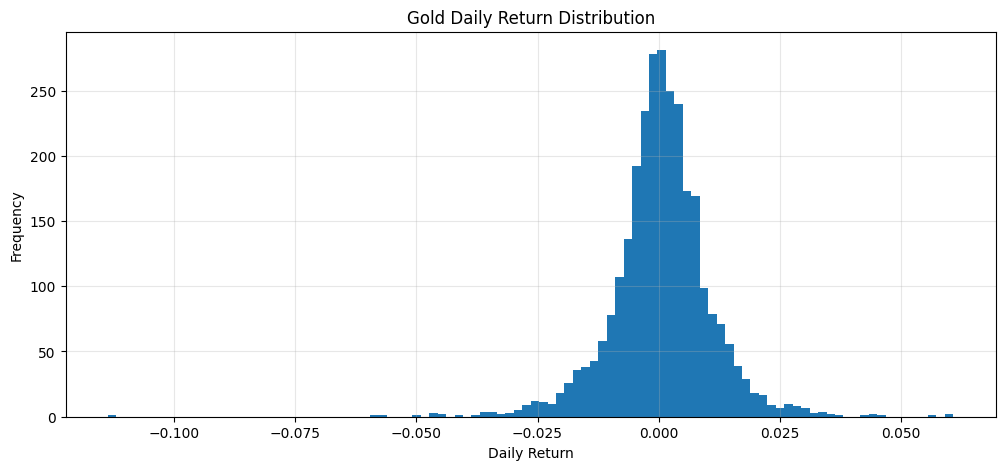

In [71]:
plot_return_distribution(
    gold,
    "Gold"
)

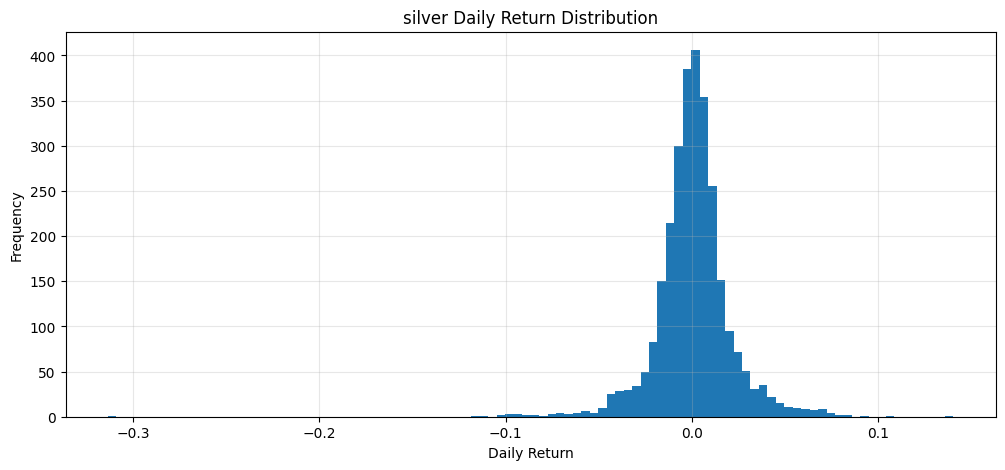

In [73]:
plot_return_distribution(
    silver,
    "silver"
)

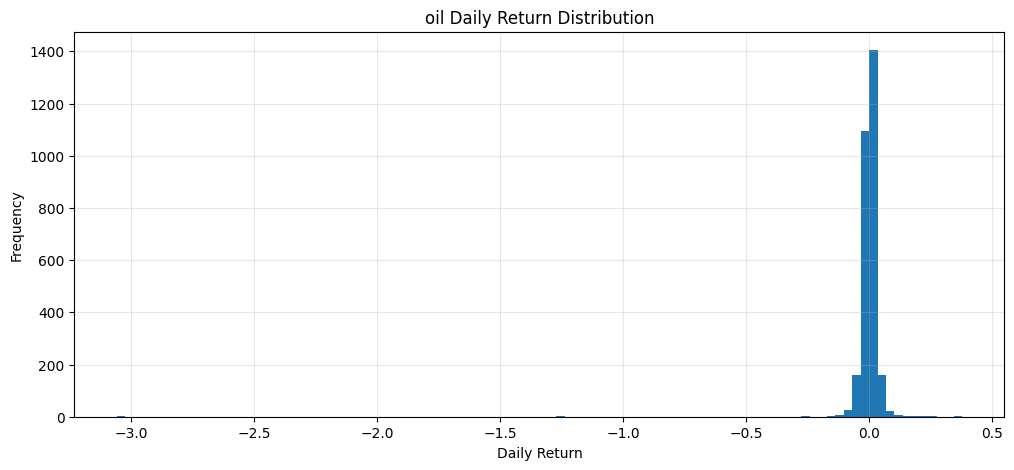

In [72]:
plot_return_distribution(
    oil,
    "oil"
)

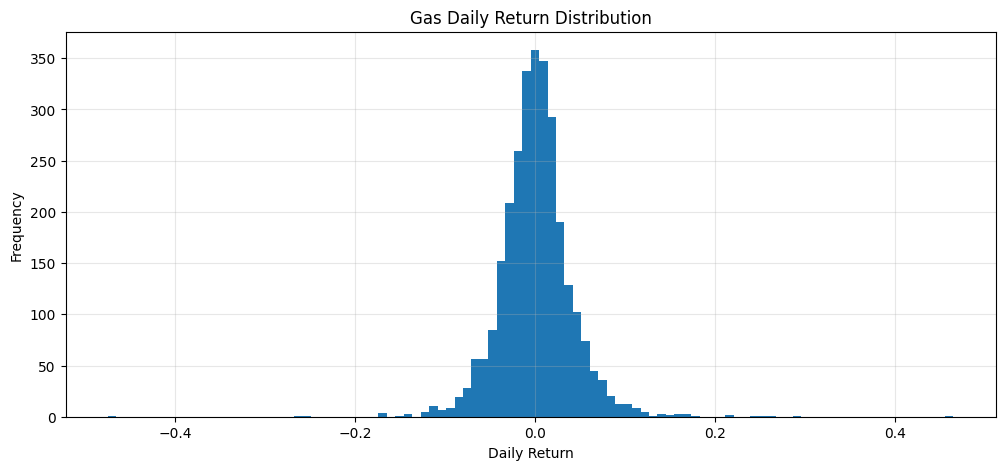

In [74]:
plot_return_distribution(
    gas,
    "Gas"
)

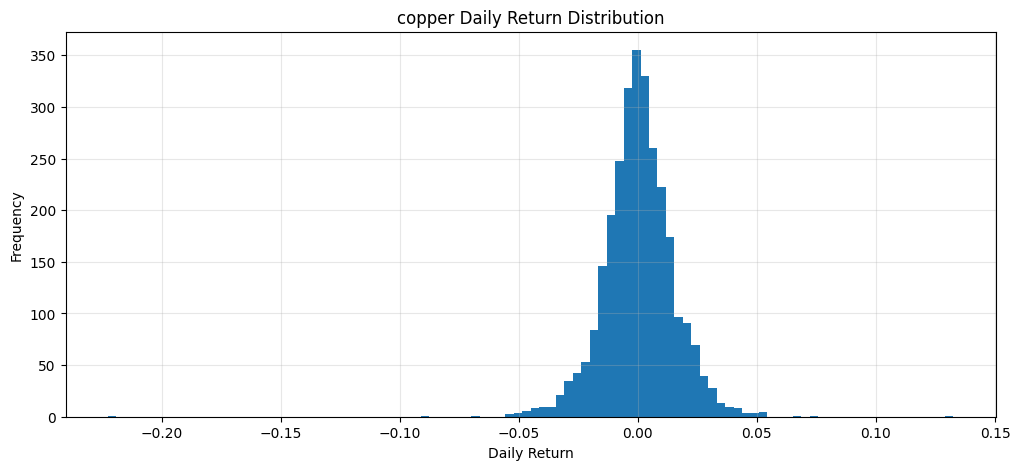

In [75]:
plot_return_distribution(
    copper,
    "copper"
)

# Return Distribution Analysis

## Objective

Return distribution analysis examines the statistical behaviour of commodity returns.

Unlike price analysis, which focuses on direction, return distributions help identify:

- Typical daily movement
- Market volatility
- Extreme gains and losses
- Tail risk
- Probability of unusual events

---

# Statistical Summary of Commodity Returns

The analysis evaluates:

- Mean daily return
- Daily volatility
- Skewness
- Kurtosis
- Best and worst trading days
- Value at Risk (VaR)

---

# Key Findings

## 🥇 Gold

Gold displayed the most stable return distribution.

### Observations

- Mean daily return: **0.048%**
- Daily volatility: **1.04%**
- Worst day: **-11.37%**
- 95% VaR: **-1.62%**

Gold showed negative skewness:

**-0.57**

indicating slightly higher probability of extreme downside movements.

However, its relatively low volatility suggests controlled risk.

### Interpretation

Gold behaves as a defensive commodity with smaller daily fluctuations compared with other assets.

---

# 🥈 Silver

Silver exhibited higher return variability than gold.

### Observations

- Mean daily return: **0.069%**
- Daily volatility: **2.10%**
- Worst day: **-31.35%**
- 95% VaR: **-3.06%**

The kurtosis value:

**21.08**

indicates heavy tails.

### Interpretation

Silver experiences more frequent extreme movements compared with gold.

Its higher return potential comes with significantly larger downside risk.

---

# 🛢️ Crude Oil

Crude oil displayed the most extreme return distribution.

### Observations

- Mean daily return: **-0.075%**
- Daily volatility: **6.82%**
- Worst day: **-305.97%**
- 95% VaR: **-4.05%**

The extremely high kurtosis:

**1439**

indicates severe tail events.

### Data Consideration

The extreme values are caused by the April 2020 WTI crude oil price collapse, when futures prices temporarily became negative.

Percentage returns become highly distorted when prices approach zero or become negative.

### Interpretation

Crude oil is highly sensitive to:

- Supply shocks
- Storage constraints
- Geopolitical events
- Demand disruptions

It represents the highest market risk among analyzed commodities.

---

# 🔥 Natural Gas

Natural gas showed the highest normal volatility after crude oil.

### Observations

- Mean daily return: **0.088%**
- Daily volatility: **4.19%**
- Best day: **46.48%**
- Worst day: **-47.48%**
- 95% VaR: **-6.12%**

The kurtosis:

**15.07**

shows frequent extreme price movements.

### Interpretation

Natural gas has highly unstable returns due to:

- Weather dependence
- Seasonal demand
- Storage levels
- Supply disruptions

It behaves as a highly speculative commodity.

---

# 🏭 Copper

Copper displayed a moderate risk-return profile.

### Observations

- Mean daily return: **0.039%**
- Daily volatility: **1.53%**
- Worst day: **-22.25%**
- 95% VaR: **-2.34%**

### Interpretation

Copper has:

- Lower volatility than precious metals
- Lower tail risk than energy commodities
- More stable industrial demand

---

# Risk Comparison Using VaR

## 95% Value at Risk

VaR estimates the expected maximum daily loss under normal market conditions.

|Commodity|95% VaR|
|-|-:|
|Gold|-1.62%|
|Copper|-2.34%|
|Silver|-3.06%|
|Crude Oil|-4.05%|
|Natural Gas|-6.12%|

---

# Overall Return Distribution Insights

## Stability Ranking

Most stable → Least stable:

1. Gold
2. Copper
3. Silver
4. Natural Gas
5. Crude Oil


## Tail Risk Ranking

Highest extreme-event risk:

1. Crude Oil
2. Natural Gas
3. Silver
4. Copper
5. Gold


---

# Final Analyst Conclusion

Commodity returns are not normally distributed.

All commodities exhibit:

- Negative or positive skewness
- High kurtosis
- Extreme return events

This indicates that commodity markets contain significant tail risk and cannot be evaluated using average returns alone.

Gold provides the most stable return profile, while energy commodities show the highest vulnerability to market shocks.

The next stage of analysis focuses on **volatility dynamics over time**, identifying periods of increasing risk and market stress.

VOLATILITY ANALYSIS objectives:

We answer:

When did commodity risk increase?
Which commodities experience volatility shocks?
Are volatility spikes temporary or persistent?
Can volatility be used for risk monitoring?

In [89]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [77]:
from analytics import calculate_rolling_volatility

In [78]:
volatility_data = {}


for name, df in commodities.items():

    volatility_data[name] = (
        calculate_rolling_volatility(df)
    )

In [79]:
volatility_data["gold"].head(35)

,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Rolling_30_Volatility
Date,,,,,,,,
2015-01-02,1186.000000,1186.000000,1194.500000,1169.500000,1184.000000,138,NaN,NaN
2015-01-05,1203.900024,1203.900024,1206.900024,1180.099976,1180.300049,470,0.015093,NaN
2015-01-06,1219.300049,1219.300049,1220.000000,1203.500000,1203.500000,97,0.012792,NaN
2015-01-07,1210.599976,1210.599976,1219.199951,1210.599976,1219.199951,29,-0.007135,NaN
2015-01-08,1208.400024,1208.400024,1215.699951,1206.300049,1207.000000,92,-0.001817,NaN
2015-01-09,1216.000000,1216.000000,1220.199951,1210.300049,1211.099976,43,0.006289,NaN
2015-01-12,1232.699951,1232.699951,1234.400024,1219.099976,1224.199951,100,0.013734,NaN
2015-01-13,1234.300049,1234.300049,1239.300049,1230.300049,1239.199951,20,0.001298,NaN
2015-01-14,1234.400024,1234.400024,1243.800049,1225.599976,1229.599976,21,0.000081,NaN


In [85]:
import visualisation
importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

In [86]:
from visualisation import plot_rolling_volatility

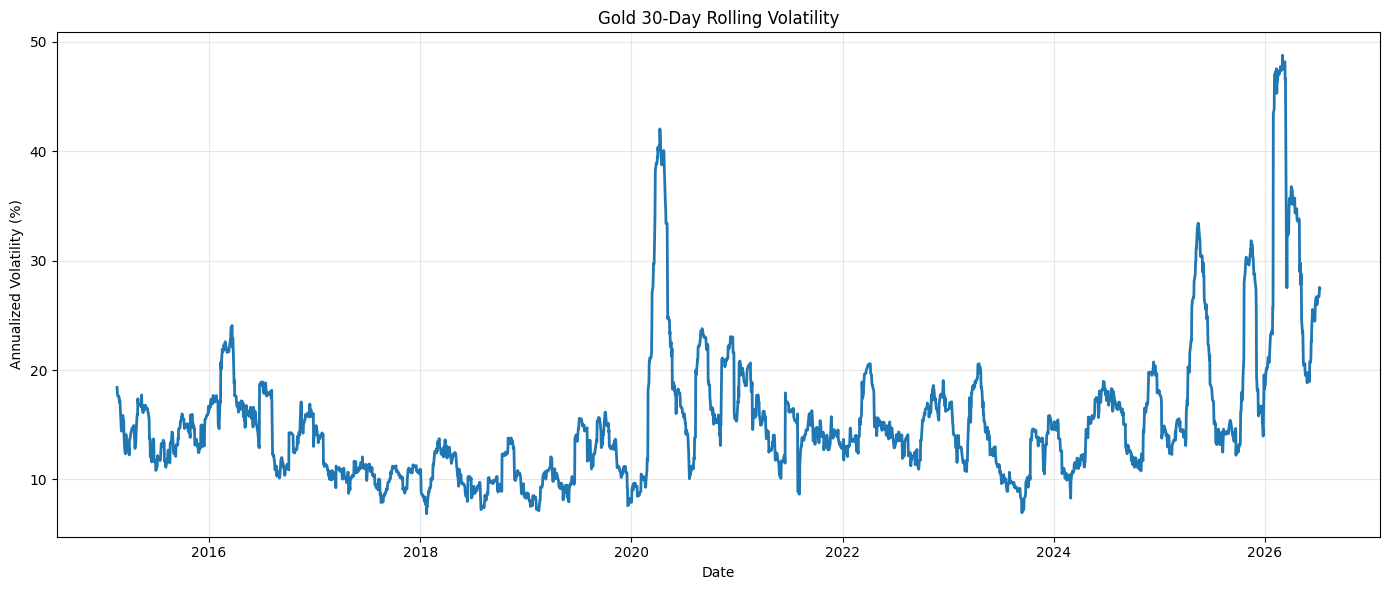

In [87]:
plot_rolling_volatility(
    volatility_data["gold"],
    "Gold"
)

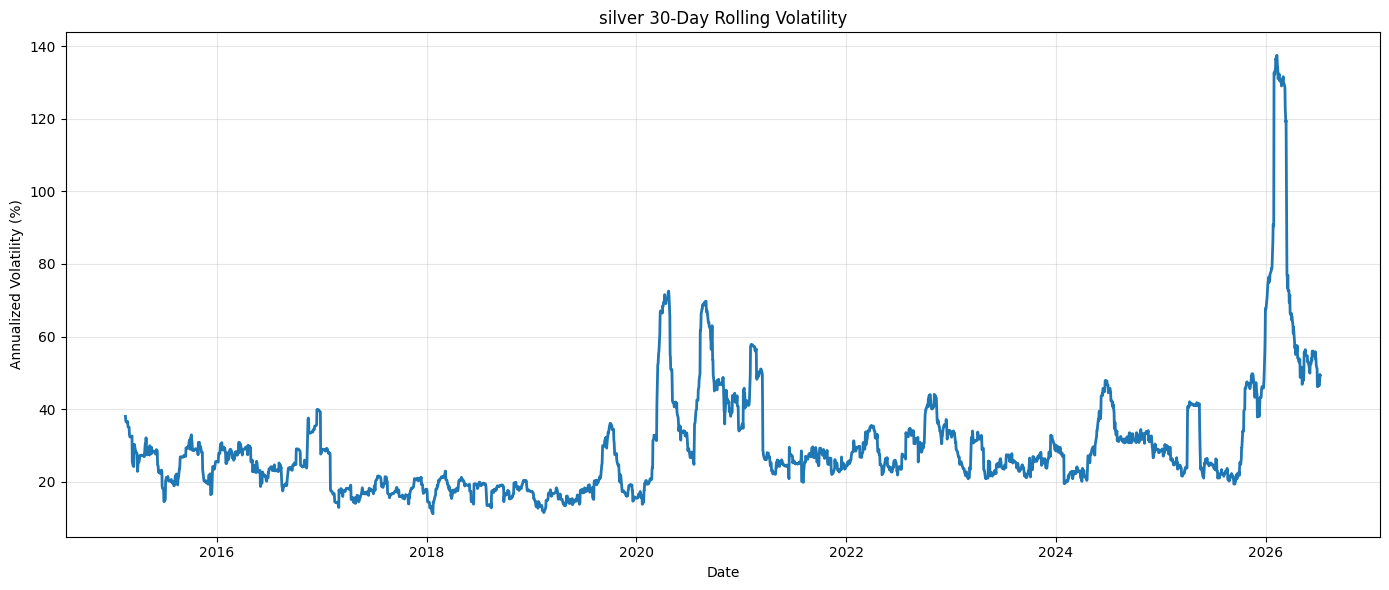

In [92]:
plot_rolling_volatility(
    volatility_data["silver"],
    "silver"
)

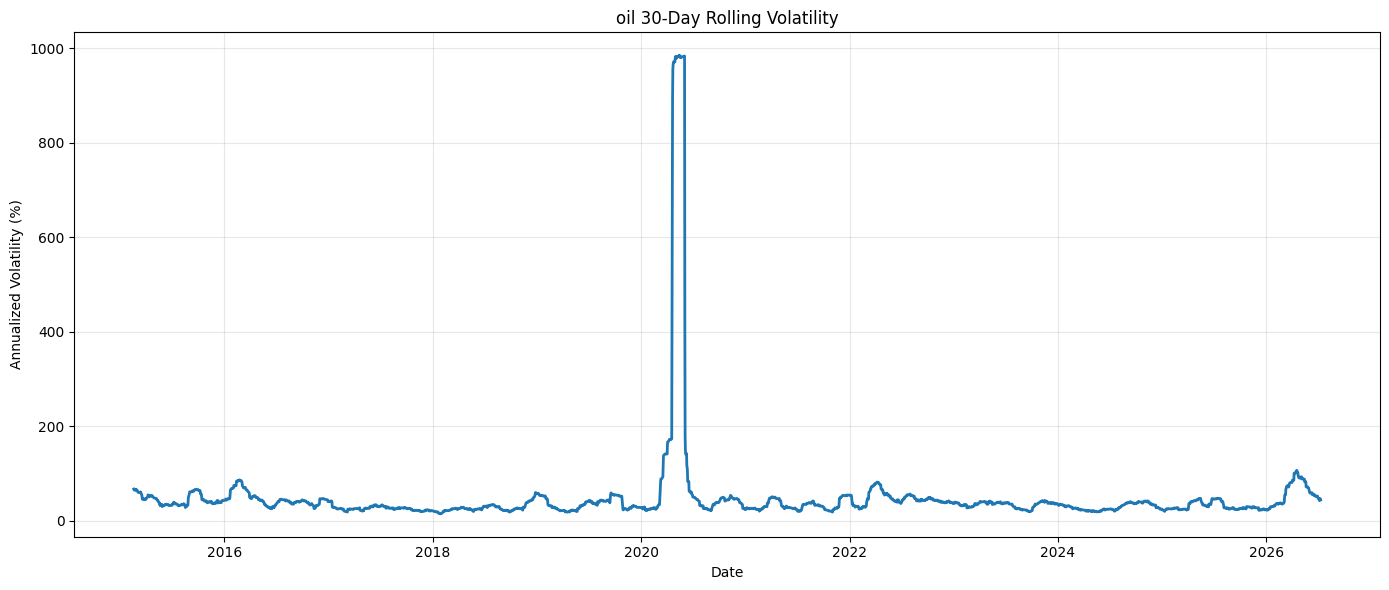

In [95]:
plot_rolling_volatility(
    volatility_data["crude_oil"],
    "oil"
)

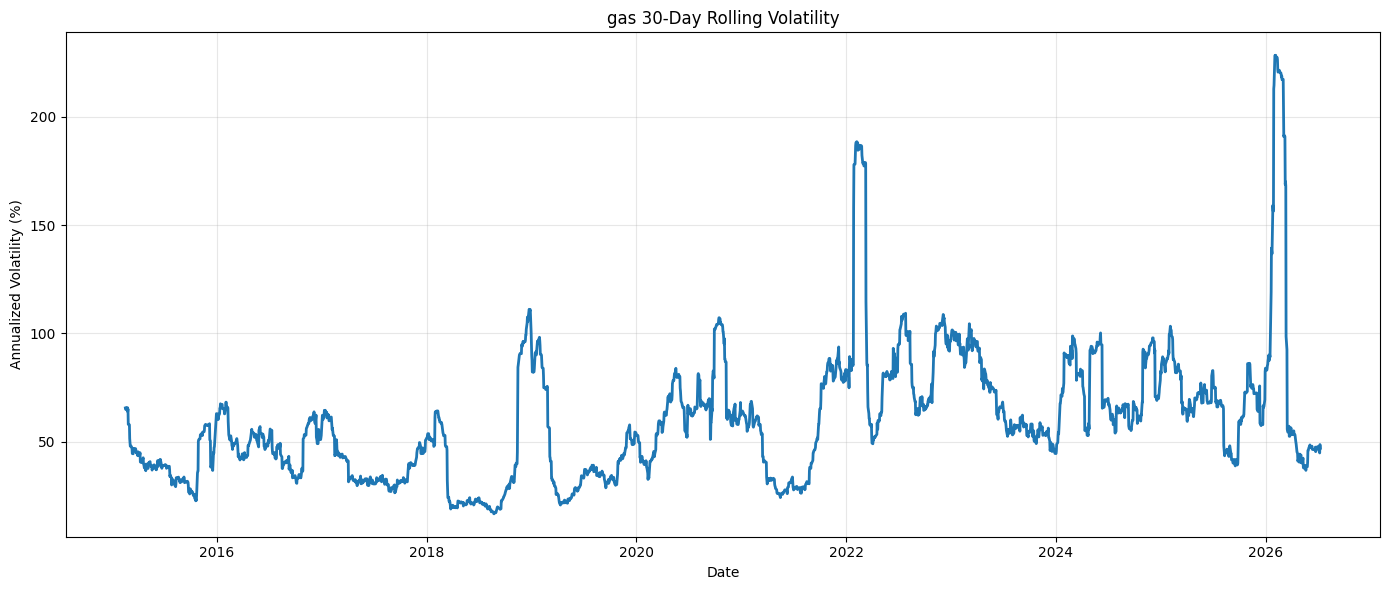

In [97]:
plot_rolling_volatility(
    volatility_data["natural_gas"],
    "gas"
)

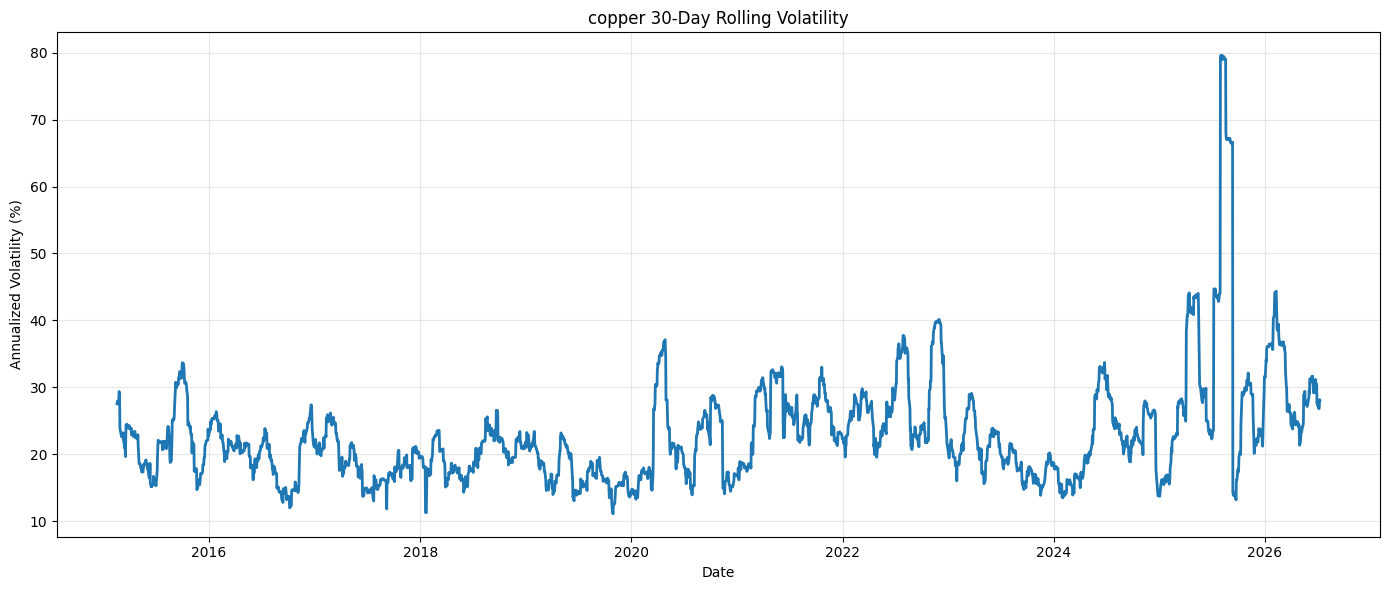

In [98]:
plot_rolling_volatility(
    volatility_data["copper"],
    "copper"
)

In [90]:
import importlib
import analytics

importlib.reload(analytics)

from analytics import volatility_summary

In [91]:
vol_summary=[]


for name,df in volatility_data.items():

    result = volatility_summary(df)

    result["Commodity"]=name

    vol_summary.append(result)



volatility_analysis = pd.concat(
    vol_summary,
    ignore_index=True
)


volatility_analysis

,Average Volatility (%),Maximum Volatility (%),Minimum Volatility (%),Commodity
0,15.24,48.79,6.86,gold
1,29.39,137.48,11.16,silver
2,47.45,985.01,14.34,crude_oil
3,59.53,228.40,16.78,natural_gas
4,22.94,79.60,11.12,copper


# Rolling Volatility Analysis

## Objective

Annualized volatility provides a single measure of risk over the entire sample period. However, market risk changes over time as commodity markets alternate between stable periods and episodes of extreme uncertainty.

To capture these changing market conditions, a **30-day rolling annualized volatility** was calculated for each commodity.

Rolling volatility measures how the variability of daily returns evolves through time, allowing us to identify periods of heightened market stress and relative stability.

---

## Volatility Summary

| Commodity | Average Volatility | Maximum Volatility | Minimum Volatility |
|-----------|-------------------:|-------------------:|-------------------:|
| Gold | **15.24%** | **48.79%** | **6.86%** |
| Silver | **29.39%** | **137.48%** | **11.16%** |
| Crude Oil | **47.45%** | **985.01%** | **14.34%** |
| Natural Gas | **59.53%** | **228.40%** | **16.78%** |
| Copper | **22.94%** | **79.60%** | **11.12%** |

---

# Commodity-wise Interpretation

## 🥇 Gold

- Recorded the **lowest average rolling volatility (15.24%)** among all commodities.
- Volatility remained relatively stable throughout the study period.
- Temporary increases coincided with periods of economic uncertainty before returning to normal levels.
- These characteristics reinforce gold's reputation as a relatively stable safe-haven asset.

---

## 🥈 Silver

- Average volatility (**29.39%**) was almost twice that of gold.
- Experienced several periods of elevated market uncertainty.
- Maximum rolling volatility reached **137.48%**, reflecting strong reactions to both industrial demand and investor sentiment.
- Silver offers higher growth potential but requires investors to tolerate greater price fluctuations.

---

## 🛢️ Crude Oil

- Recorded one of the highest average volatility levels (**47.45%**).
- Maximum rolling volatility surged to **985.01%**, driven by the historic negative oil price event during April 2020.
- Oil prices remain highly sensitive to geopolitical events, production decisions, and global demand shocks.

---

## 🔥 Natural Gas

- Exhibited the **highest average rolling volatility (59.53%)** among all commodities.
- Maximum volatility reached **228.40%**, reflecting repeated supply disruptions and seasonal demand fluctuations.
- Unlike crude oil, natural gas experienced frequent volatility spikes throughout the sample period rather than one isolated event.

---

## 🏭 Copper

- Displayed moderate average volatility (**22.94%**).
- Volatility increased during periods of economic slowdown and changing industrial demand.
- Copper maintained a relatively stable risk profile compared with energy commodities.

---

# Comparative Risk Ranking

## Average Rolling Volatility

| Rank | Commodity | Average Volatility |
|-----:|-----------|-------------------:|
| 1 | Natural Gas | **59.53%** |
| 2 | Crude Oil | **47.45%** |
| 3 | Silver | **29.39%** |
| 4 | Copper | **22.94%** |
| 5 | Gold | **15.24%** |

---

# Business Insights

- **Gold** maintained the most stable risk profile, making it suitable for investors seeking capital preservation.
- **Silver** provided stronger return potential but with substantially greater market risk.
- **Crude Oil** experienced the largest volatility spike due to extraordinary market disruptions, highlighting its exposure to geopolitical and supply-side shocks.
- **Natural Gas** consistently exhibited the highest day-to-day uncertainty, making it the riskiest commodity for short-term trading.
- **Copper** demonstrated a balanced combination of moderate volatility and long-term industrial growth.

---

# Conclusion

Rolling volatility confirms that commodity market risk is dynamic rather than constant. Precious metals generally exhibited more stable risk characteristics, whereas energy commodities experienced larger and more frequent volatility spikes.

Monitoring rolling volatility is valuable for portfolio risk management, asset allocation, and forecasting future market uncertainty because it highlights periods when market risk changes significantly over time.

Correlation Analysis:
How do these commodities move relative to one another?

In [100]:
import importlib
import analytics

importlib.reload(analytics)

<module 'analytics' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\analytics.py'>

In [101]:
import importlib
import visualisation

importlib.reload(visualisation)

<module 'visualisation' from 'C:\\Users\\ujjwa\\OneDrive\\Documents\\commodity-analytics\\src\\visualisation.py'>

In [102]:
from analytics import correlation_matrix

In [103]:
corr = correlation_matrix(
    merged.set_index("Date")
)

corr

C:\Users\ujjwa\OneDrive\Documents\commodity-analytics\src\analytics.py:398: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


,gold,silver,crude_oil,natural_gas,copper
gold,1.000000,0.774941,0.026085,0.018364,0.279147
silver,0.774941,1.000000,0.048931,0.016742,0.404921
crude_oil,0.026085,0.048931,1.000000,0.014447,0.111960
natural_gas,0.018364,0.016742,0.014447,1.000000,0.012571
copper,0.279147,0.404921,0.111960,0.012571,1.000000


In [104]:
from visualisation import plot_correlation_heatmap

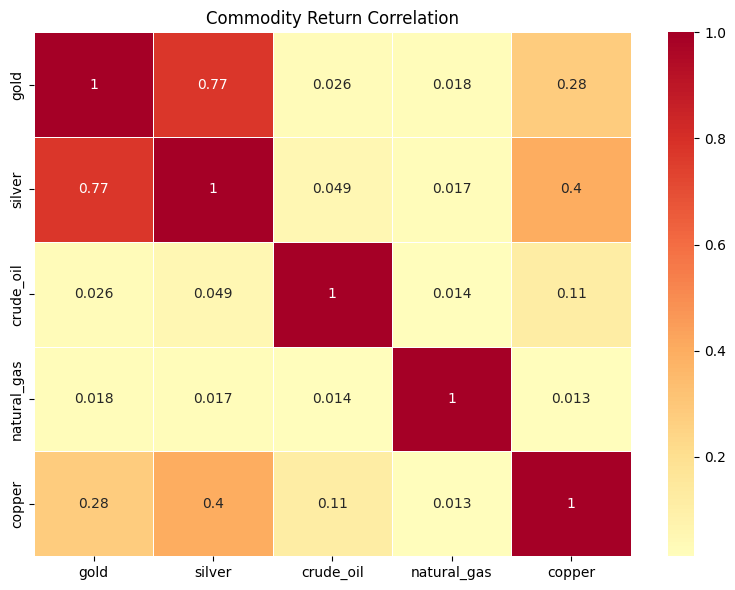

In [105]:
plot_correlation_heatmap(corr)

In [106]:
from analytics import rolling_correlation

In [107]:
gold_silver = rolling_correlation(
    gold,
    silver
)

gold_silver.head()

Date
2015-01-02   NaN
2015-01-05   NaN
2015-01-06   NaN
2015-01-07   NaN
2015-01-08   NaN
Name: Close, dtype: float64

In [111]:
from visualisation import plot_rolling_correlation

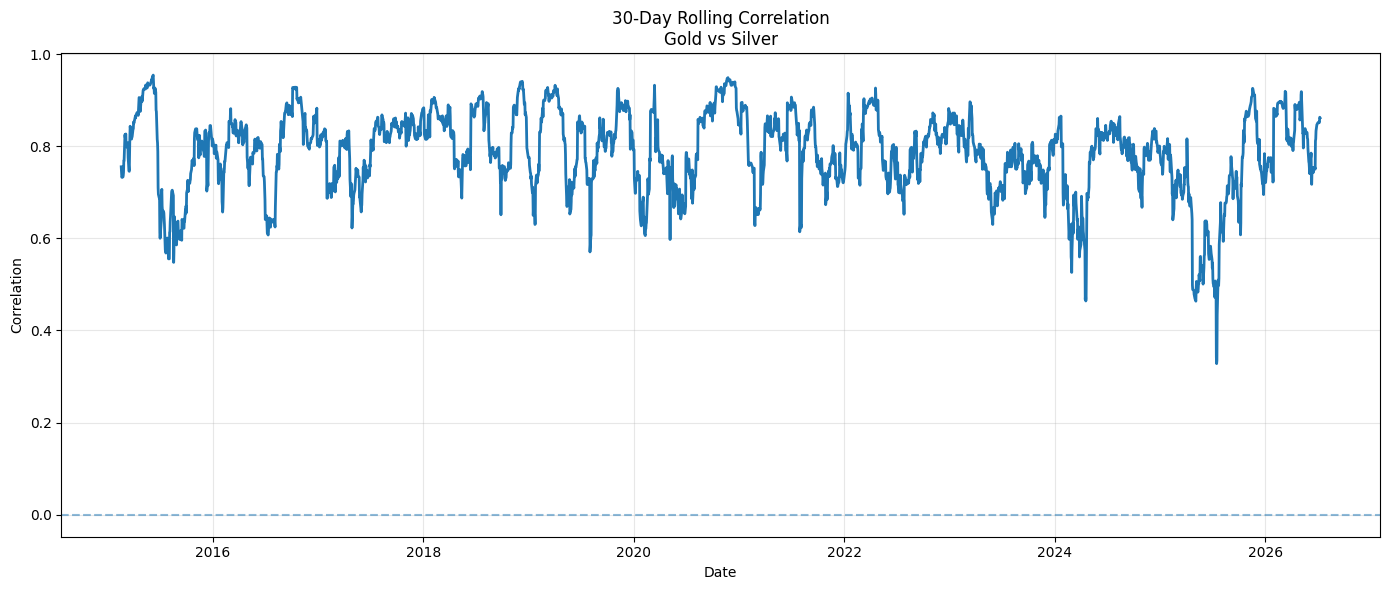

In [112]:
plot_rolling_correlation(
    gold_silver,
    "Gold",
    "Silver"
)

In [115]:
oil_gas = rolling_correlation(
    oil,
    gas
)
oil_gas

Date
2015-01-02         NaN
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
                ...   
2026-07-06   -0.192926
2026-07-07   -0.180878
2026-07-08   -0.198742
2026-07-09   -0.161538
2026-07-10   -0.073680
Name: Close, Length: 2897, dtype: float64

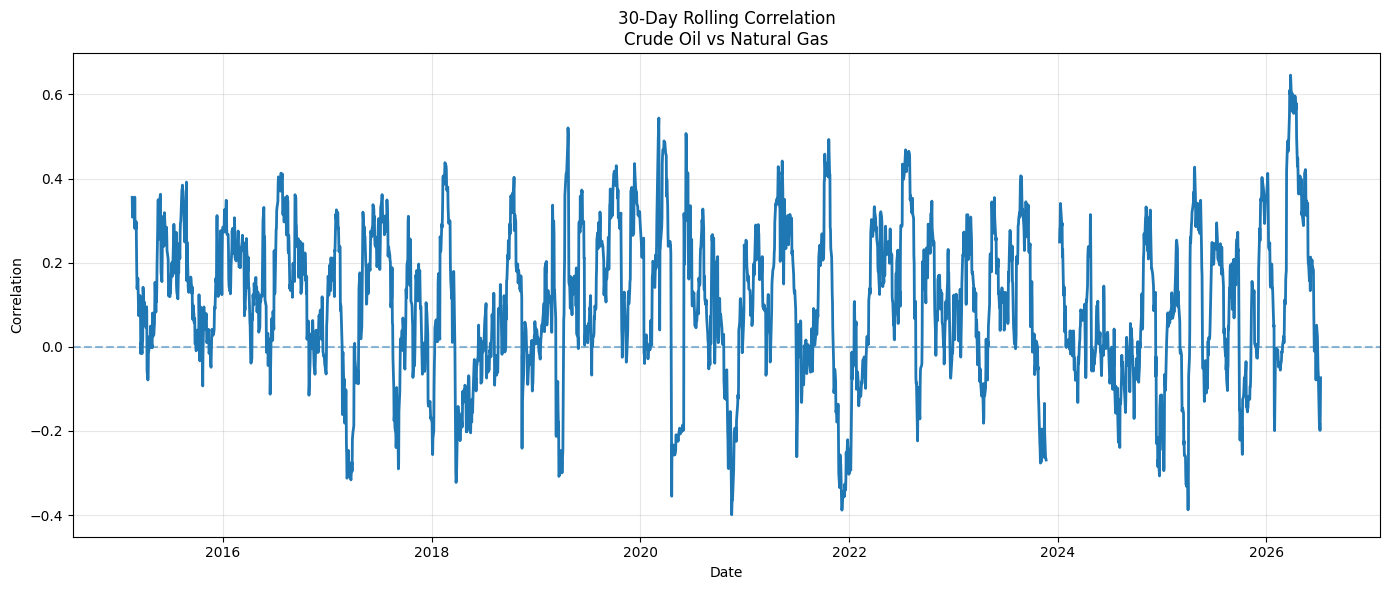

In [114]:
plot_rolling_correlation(
    oil_gas,
    "Crude Oil",
    "Natural Gas"
)

In [116]:
gold_copper = rolling_correlation(
    gold,
    copper
)
gold_copper

Date
2015-01-02         NaN
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
                ...   
2026-07-06    0.611105
2026-07-07    0.615573
2026-07-08    0.636874
2026-07-09    0.654710
2026-07-10    0.649348
Name: Close, Length: 2896, dtype: float64

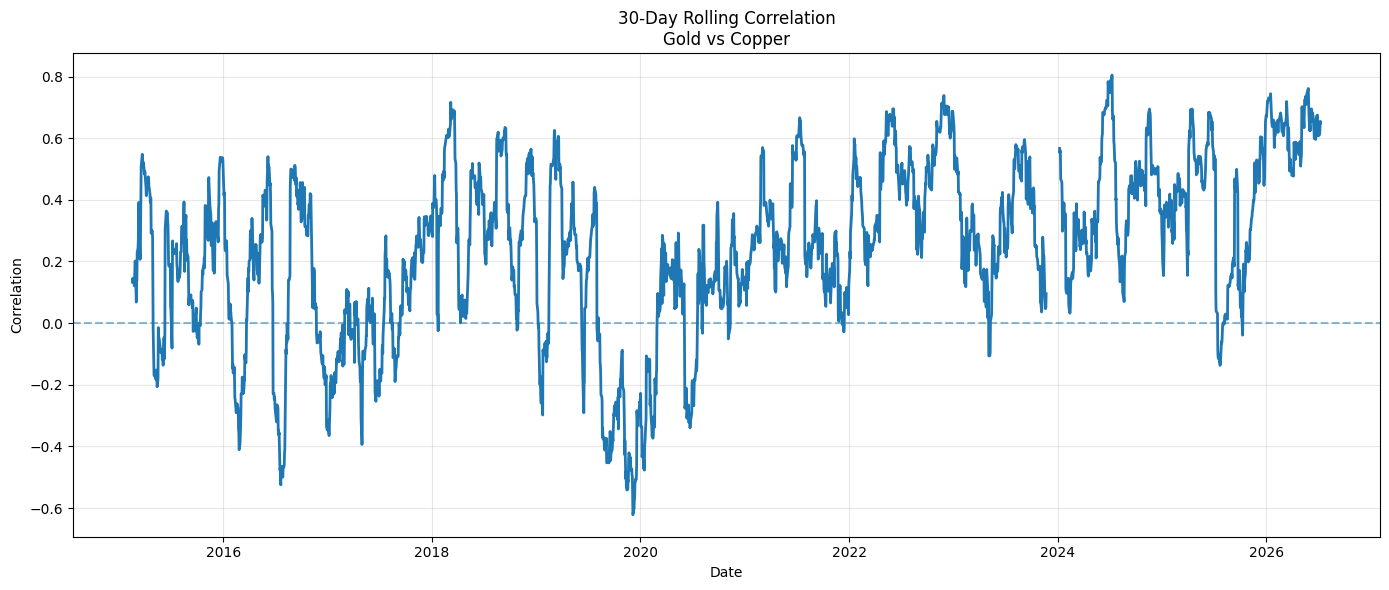

In [117]:
plot_rolling_correlation(
    gold_copper,
    "Gold",
    "Copper"
)

# Correlation Analysis

# Key Observations

### Gold and Silver

Gold and silver exhibit the strongest positive relationship in the dataset, with a correlation coefficient of **0.77**.

This strong association reflects their shared role as precious metals and investment assets. Both commodities tend to respond similarly to changes in inflation expectations, interest rates, monetary policy, and periods of economic uncertainty.

---

### Silver and Copper

Silver and copper show a moderate positive correlation (**0.40**).

Unlike gold, silver possesses significant industrial applications in electronics, solar energy, and manufacturing. Consequently, silver shares part of its price dynamics with copper, another major industrial metal.

---

### Gold and Copper

Gold and copper demonstrate a relatively weak positive relationship (**0.28**).

Although these commodities are influenced by different economic forces, periods of broad commodity market appreciation or inflationary environments can cause both assets to rise simultaneously.

---

### Crude Oil

Crude oil displays almost no correlation with precious metals or copper.

Its price movements are primarily driven by global supply-demand imbalances, geopolitical events, production decisions by oil-exporting nations, and changes in transportation demand rather than macroeconomic investment flows.

---

### Natural Gas

Natural gas exhibits the weakest correlations with every other commodity.

This independence is expected because natural gas prices are strongly influenced by seasonal weather conditions, regional infrastructure, storage capacity, and localized supply disruptions rather than broader commodity market trends.

---

# Rolling Correlation Analysis

Static correlation summarizes the average relationship over the entire study period. However, financial markets are dynamic, and relationships between assets evolve over time.

To capture these changing relationships, a **30-day rolling correlation** was calculated for selected commodity pairs.

---

# Gold vs Silver

### Observations

- The rolling correlation remained consistently positive throughout the study period.
- Most values ranged between **0.60 and 0.95**.
- Correlation never became negative.
- Temporary declines occurred during periods of increased silver-specific volatility.

### Interpretation

Gold and silver maintain a strong structural relationship because both function as precious metals, inflation hedges, and safe-haven investments.

Short-lived declines in correlation likely reflect silver's greater sensitivity to industrial demand and its naturally higher volatility. Despite these temporary deviations, the two commodities generally move together over time.

---

# Crude Oil vs Natural Gas

### Observations

- Rolling correlation fluctuated widely between approximately **-0.40 and +0.40**.
- Correlation frequently crossed zero.
- Only occasional short periods exhibited moderately positive correlation.

### Interpretation

Although both commodities belong to the energy sector, their underlying market drivers differ substantially.

Crude oil is influenced primarily by global transportation demand, geopolitical developments, and OPEC production policies. Natural gas prices depend more heavily on seasonal weather patterns, storage inventories, and regional supply conditions.

The frequent movement between positive and negative correlation indicates that these commodities behave largely independently.

---

# Gold vs Copper

### Observations

- Between **2015 and 2020**, rolling correlation fluctuated between positive and negative values.
- Around early 2020, correlation briefly became strongly negative.
- After 2020, correlation shifted toward a sustained positive relationship, generally remaining between **0.20 and 0.80**.

### Interpretation

Gold and copper represent two fundamentally different economic themes.

Gold is traditionally viewed as a defensive asset that performs well during periods of uncertainty, whereas copper is considered a leading indicator of industrial activity and global economic growth.

Before 2020, these differing characteristics often resulted in opposite price movements. Following the pandemic, broad macroeconomic forces—including inflation, supply chain disruptions, and expansive monetary policy—supported prices across many physical assets, producing a stronger positive relationship between gold and copper.

---

# Business Insights

- Gold and silver provide similar market exposure and therefore offer relatively limited diversification benefits when held together.
- Copper exhibits moderate diversification potential while still maintaining some connection to broader commodity market trends.
- Crude oil behaves largely independently from precious metals, making it a useful asset for diversification despite its higher volatility.
- Natural gas demonstrates the greatest degree of independence, reflecting its unique supply-demand fundamentals and regional market dynamics.
- Rolling correlations reveal that relationships between commodities are not constant and may change substantially during periods of economic stress or structural market shifts.

---

# Conclusion

The correlation analysis demonstrates that commodity relationships vary considerably across asset classes.

Precious metals exhibit strong and persistent co-movement, industrial metals show moderate relationships, while energy commodities—particularly natural gas—operate under fundamentally different market conditions.

Furthermore, rolling correlation analysis highlights that these relationships evolve through time, emphasizing the importance of dynamic risk management rather than relying solely on long-term average correlations.